It uses the fully enriched modeling table:

```text
data/processed/calfire_with_gridmet_terrain_drought_veg.csv
```

The table combines:

```text
CAL FIRE incident records
gridMET weather and fire-danger variables
USGS 3DEP terrain features
U.S. Drought Monitor drought features
LANDFIRE vegetation and fuel features
```

Main goals:

1. Audit data quality and missingness.
2. Justify the severity-tier target.
3. Explore temporal, seasonal, and spatial patterns.
4. Compare weather/fire-danger, terrain, drought, and vegetation features across severity tiers.
5. Identify feature redundancy and potential modeling issues.
6. Check the proposed time-based train/test split.
7. Produce concise final EDA conclusions for the README and report.


## Import necessary packages

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Creating variables for directories

In [2]:
PROJECT_ROOT = Path.cwd()
PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "final_eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = PROCESSED_DIR / "calfire_with_gridmet_terrain_drought_veg.csv"

print("Project root:", PROJECT_ROOT)
print("Input path:", INPUT_PATH)
print("Output directory:", OUTPUT_DIR)


Project root: c:\Users\chaud\Desktop\repositories\wildfire-severity-v2
Input path: c:\Users\chaud\Desktop\repositories\wildfire-severity-v2\data\processed\calfire_with_gridmet_terrain_drought_veg.csv
Output directory: c:\Users\chaud\Desktop\repositories\wildfire-severity-v2\outputs\final_eda


## 1. Load file

In [3]:
df = pd.read_csv(INPUT_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.tail())


Shape: (2397, 197)


,gridmet_id,UniqueId,Name,StartedDateOnly,Latitude,Longitude,AcresBurned,gridmet_rows_available,n_days_7d,pr_mm_7d_mean,...,is_extreme_D3_plus,usdm_missing_reason,fbfm40_code,evt_code,evc_code,evh_code,canopy_cover,fvt_code,fvc_code,fbfm40_group
0,fire_00000,3135c367-1274-4cc4-9152-661f6fd7707e,Creek Fire,2016-10-10,38.409580,-122.431720,65.0,30,7,0.200000,...,0.0,NaN,183.0,7901.0,14.0,14.0,45.0,2914.0,14.0,timber_litter
1,fire_00001,7106ba43-100b-41f9-acbf-9fb9e9ab9ef7,Taglio Fire,2016-04-24,37.217100,-121.080360,30.0,30,7,0.185714,...,1.0,NaN,93.0,7984.0,64.0,64.0,0.0,2964.0,64.0,nonburnable_or_other
2,fire_00002,ffec404e-dea9-4175-8c50-8f2b0ca3efdd,Tulloch Fire,2016-05-30,37.927613,-120.528836,85.0,30,7,0.000000,...,1.0,NaN,102.0,9301.0,351.0,304.0,0.0,2270.0,125.0,grass
3,fire_00003,55fa95e6-f09e-42c4-889b-a4b5b63dccf2,Metz Fire,2016-05-22,36.381230,-121.200590,3876.0,30,7,0.000000,...,1.0,NaN,102.0,9301.0,342.0,303.0,0.0,2184.0,123.0,grass
4,fire_00004,ace1f464-7a70-4dcc-b8c5-d64fb1021d0e,Wheatland Fire,2016-05-23,34.276000,-118.354000,156.0,30,7,0.000000,...,1.0,NaN,122.0,7092.0,224.0,215.0,0.0,2092.0,112.0,grass_shrub


,gridmet_id,UniqueId,Name,StartedDateOnly,Latitude,Longitude,AcresBurned,gridmet_rows_available,n_days_7d,pr_mm_7d_mean,...,is_extreme_D3_plus,usdm_missing_reason,fbfm40_code,evt_code,evc_code,evh_code,canopy_cover,fvt_code,fvc_code,fbfm40_group
2392,fire_02399,d64ada14-14ac-4ef6-a77b-495b6b17136f,Addie Fire,2024-12-14,35.272480,-119.615510,30.0,30,7,0.0,...,0.0,NaN,121.0,9301.0,321.0,303.0,0.0,2270.0,122.0,grass_shrub
2393,fire_02400,6d5fa9cd-13a8-4f93-8a28-de9895dc9a30,Soto Fire,2024-12-17,34.002023,-117.440844,25.0,30,7,0.0,...,0.0,NaN,91.0,7297.0,23.0,23.0,0.0,2903.0,23.0,nonburnable_or_other
2394,fire_02401,c991981e-892b-449a-b467-b5f742a4e9b1,Soda Fire,2024-12-21,34.986800,-119.477000,419.0,30,7,0.0,...,0.0,NaN,102.0,9301.0,334.0,303.0,0.0,2270.0,123.0,grass
2395,fire_02402,bdead44e-0ddf-4a1a-ad05-440493024012,Five Fire,2024-07-14,35.385869,-119.367525,360.0,30,7,0.0,...,0.0,NaN,99.0,9062.0,31.0,31.0,0.0,31.0,31.0,nonburnable_or_other
2396,fire_02403,6339e262-6ccf-4d19-8436-44e508d43ba6,Five 2 Fire,2024-07-15,35.587955,-119.624655,347.0,30,7,0.0,...,0.0,NaN,122.0,9829.0,334.0,303.0,0.0,2280.0,123.0,grass_shrub


## 2. Ensuring dataset is ready for EDA and modelling


In [4]:
required_cols = [
    "gridmet_id",
    "Name",
    "Latitude",
    "Longitude",
    "AcresBurned",
    "severity_tier",
    "nwcg_size_class",
    "year",
    "month",
]

missing_required = [c for c in required_cols if c not in df.columns]
print("Missing required columns:", missing_required)

print("\nDataset shape:", df.shape)

if "gridmet_id" in df.columns:
    print("Duplicate gridmet_id rows:", df["gridmet_id"].duplicated().sum())

if {"Latitude", "Longitude"}.issubset(df.columns):
    print("\nLatitude range:", df["Latitude"].min(), "to", df["Latitude"].max())
    print("Longitude range:", df["Longitude"].min(), "to", df["Longitude"].max())
    print("Rows outside California-ish latitude:", (~df["Latitude"].between(32, 42)).sum())
    print("Rows outside California-ish longitude:", (~df["Longitude"].between(-125, -113)).sum())

if "AcresBurned" in df.columns:
    df["AcresBurned"] = pd.to_numeric(df["AcresBurned"], errors="coerce")
    print("\nMissing AcresBurned:", df["AcresBurned"].isna().sum())
    print("AcresBurned <= 0:", (df["AcresBurned"] <= 0).sum())

if "severity_tier" in df.columns:
    print("\nSeverity tier missing:", df["severity_tier"].isna().sum())
    display(df["severity_tier"].value_counts(dropna=False).to_frame("count"))


Missing required columns: []

Dataset shape: (2397, 197)
Duplicate gridmet_id rows: 0

Latitude range: 32.557546 to 41.99483
Longitude range: -124.362017 to -114.276308
Rows outside California-ish latitude: 0
Rows outside California-ish longitude: 0

Missing AcresBurned: 0
AcresBurned <= 0: 0

Severity tier missing: 0


,count
severity_tier,
Small,1311
Medium,720
Large,200
Extreme,166


In [5]:
missingness = df.isna().mean().sort_values(ascending=False).to_frame("missing_fraction")
missingness["missing_count"] = df.isna().sum()

display(missingness.head(40))
missingness.to_csv(OUTPUT_DIR / "missingness_summary.csv")


,missing_fraction,missing_count
usdm_missing_reason,0.995828,2387
usdm_category,0.525240,1259
is_severe_D2_plus,0.004172,10
is_drought_D1_plus,0.004172,10
usdm_intensity,0.004172,10
is_extreme_D3_plus,0.004172,10
is_abnormally_dry_D0_plus,0.004172,10
evc_code,0.003755,9
n_days_7d,0.000000,0
pr_mm_7d_mean,0.000000,0


## 3. Clean display fields and define features
- `severity_tier` is ordered as Small, Medium, Large, Extreme.
- `usdm_category` may display `None` as missing when read from CSV, so `usdm_category_display` is created only for EDA display.
- `has_canopy_cover` is created because canopy cover is often zero-heavy.


In [6]:
tier_order = ["Small", "Medium", "Large", "Extreme"]

if "severity_tier" in df.columns:
    df["severity_tier"] = pd.Categorical(df["severity_tier"], categories=tier_order, ordered=True)

# Ensure numeric fields are numeric.
for col in ["year", "month", "Latitude", "Longitude", "AcresBurned", "log_acres"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [7]:
# Temperature readability conversions.
new_cols = {}
if "tmmx_K_7d_mean" in df.columns and "tmmx_F_7d_mean" not in df.columns:
    new_cols["tmmx_F_7d_mean"] = (df["tmmx_K_7d_mean"] - 273.15) * 9 / 5 + 32
if "tmmn_K_7d_mean" in df.columns and "tmmn_F_7d_mean" not in df.columns:
    new_cols["tmmn_F_7d_mean"] = (df["tmmn_K_7d_mean"] - 273.15) * 9 / 5 + 32
if new_cols:
    df = df.assign(**new_cols).copy()

C:\Users\chaud\AppData\Local\Temp\ipykernel_15760\528558659.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.assign(**new_cols).copy()


In [8]:
# Drought display cleanup.
if "usdm_category" in df.columns:
    df["usdm_category_display"] = df["usdm_category"].copy()
    if "usdm_intensity" in df.columns:
        df["usdm_intensity"] = pd.to_numeric(df["usdm_intensity"], errors="coerce")
        df.loc[df["usdm_intensity"].eq(0) & df["usdm_category_display"].isna(), "usdm_category_display"] = "None_or_D0"
        df.loc[df["usdm_intensity"].isna() & df["usdm_category_display"].isna(), "usdm_category_display"] = "Missing"

In [9]:
# Canopy cover binary feature for EDA.
if "canopy_cover" in df.columns:
    df["canopy_cover"] = pd.to_numeric(df["canopy_cover"], errors="coerce")
    df["has_canopy_cover"] = (df["canopy_cover"] > 0).astype(float)

In [10]:
# Setting up column groups for EDA focus.
weather_cols = [
    c for c in [
        "tmmx_F_7d_mean",
        "tmmn_F_7d_mean",
        "vpd_kPa_7d_mean",
        "vs_m_s_7d_mean",
        "rmin_pct_7d_mean",
        "pr_mm_30d_sum",
        "erc_7d_mean",
        "bi_7d_mean",
        "fm100_pct_7d_mean",
        "fm1000_pct_30d_mean",
    ]
    if c in df.columns
]

terrain_cols = [
    c for c in ["elevation", "slope_degrees", "aspect_degrees", "northness", "eastness"]
    if c in df.columns
]

drought_cols = [
    c for c in [
        "usdm_raw",
        "usdm_category",
        "usdm_category_display",
        "usdm_intensity",
        "is_abnormally_dry_D0_plus",
        "is_drought_D1_plus",
        "is_severe_D2_plus",
        "is_extreme_D3_plus",
    ]
    if c in df.columns
]

veg_cols = [
    c for c in [
        "fbfm40_code",
        "fbfm40_group",
        "evt_code",
        "evc_code",
        "evh_code",
        "canopy_cover",
        "has_canopy_cover",
        "fvt_code",
        "fvc_code",
    ]
    if c in df.columns
]

focus_numeric_cols = [
    c for c in weather_cols + terrain_cols + [
        "usdm_intensity",
        "is_drought_D1_plus",
        "is_severe_D2_plus",
        "is_extreme_D3_plus",
        "canopy_cover",
        "has_canopy_cover",
        "evc_code",
        "evh_code",
        "fvc_code",
    ]
    if c in df.columns
]

print("Weather/fire-danger columns:", weather_cols)
print("Terrain columns:", terrain_cols)
print("Drought columns:", drought_cols)
print("Vegetation/fuel columns:", veg_cols)
print("Focus numeric columns:", focus_numeric_cols)

Weather/fire-danger columns: ['tmmx_F_7d_mean', 'tmmn_F_7d_mean', 'vpd_kPa_7d_mean', 'vs_m_s_7d_mean', 'rmin_pct_7d_mean', 'pr_mm_30d_sum', 'erc_7d_mean', 'bi_7d_mean', 'fm100_pct_7d_mean', 'fm1000_pct_30d_mean']
Terrain columns: ['elevation', 'slope_degrees', 'aspect_degrees', 'northness', 'eastness']
Drought columns: ['usdm_raw', 'usdm_category', 'usdm_category_display', 'usdm_intensity', 'is_abnormally_dry_D0_plus', 'is_drought_D1_plus', 'is_severe_D2_plus', 'is_extreme_D3_plus']
Vegetation/fuel columns: ['fbfm40_code', 'fbfm40_group', 'evt_code', 'evc_code', 'evh_code', 'canopy_cover', 'has_canopy_cover', 'fvt_code', 'fvc_code']
Focus numeric columns: ['tmmx_F_7d_mean', 'tmmn_F_7d_mean', 'vpd_kPa_7d_mean', 'vs_m_s_7d_mean', 'rmin_pct_7d_mean', 'pr_mm_30d_sum', 'erc_7d_mean', 'bi_7d_mean', 'fm100_pct_7d_mean', 'fm1000_pct_30d_mean', 'elevation', 'slope_degrees', 'aspect_degrees', 'northness', 'eastness', 'usdm_intensity', 'is_drought_D1_plus', 'is_severe_D2_plus', 'is_extreme_D3_plu

## 4. Target distribution and acres burned skew

This section justifies why the project uses severity-tier classification instead of raw acreage regression.

Fire size is usually highly right-skewed: most fires are relatively small, but a few fires burn extremely large areas.


,count
nwcg_size_class,
B,23
C,1288
D,448
E,272
F,200
G,166


,count
severity_tier,
Small,1311
Medium,720
Large,200
Extreme,166


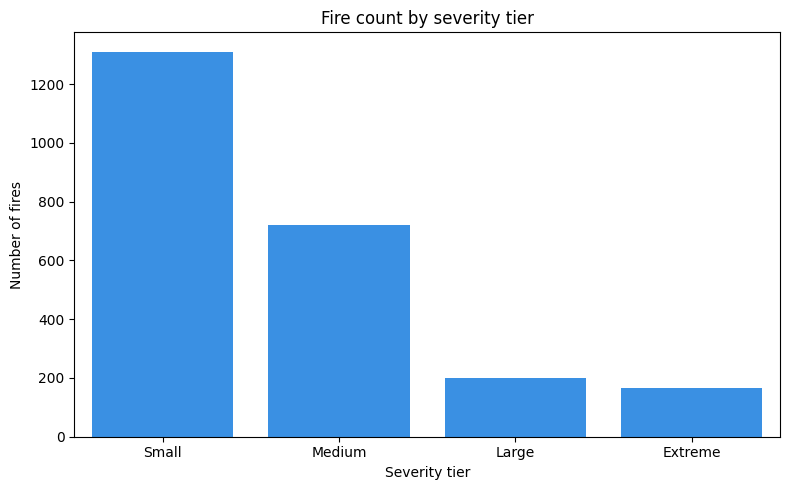

In [18]:
if "nwcg_size_class" in df.columns:
    nwcg_counts = df["nwcg_size_class"].value_counts().sort_index()
    display(nwcg_counts.to_frame("count"))
    nwcg_counts.to_csv(OUTPUT_DIR / "nwcg_size_class_counts.csv")

if "severity_tier" in df.columns:
    tier_counts = df["severity_tier"].value_counts().reindex(tier_order)
    display(tier_counts.to_frame("count"))
    tier_counts.to_csv(OUTPUT_DIR / "severity_tier_counts.csv")

    plt.figure(figsize=(8, 5))
    sns.barplot(x=tier_counts.index, 
                y=tier_counts.values, 
                order=tier_order, color = 
                'dodgerblue')
    plt.title("Fire count by severity tier")
    plt.xlabel("Severity tier")
    plt.ylabel("Number of fires")
    plt.tight_layout()
    plt.show()


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
AcresBurned,2397.0,4332.507772,37043.814666,2.0,30.0,80.0,328.0,2420.4,8806.4,83844.04,1032648.0


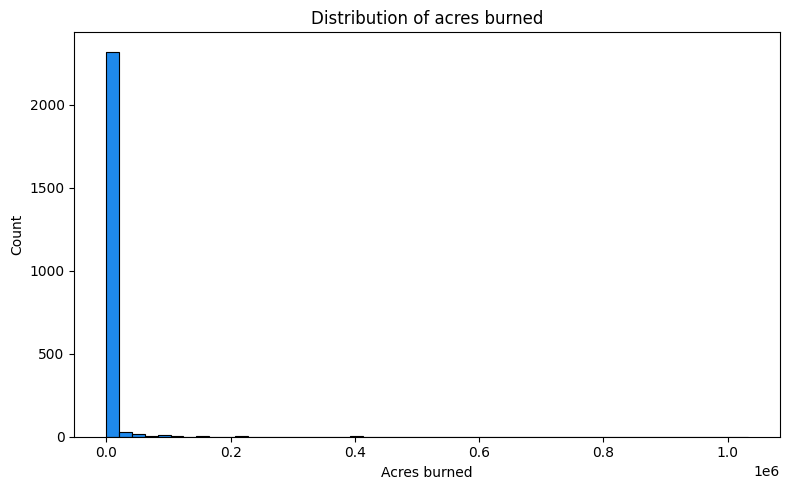

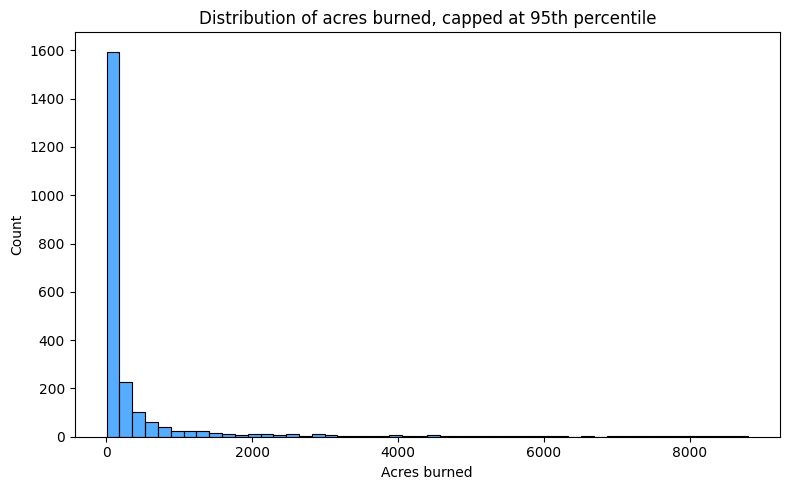

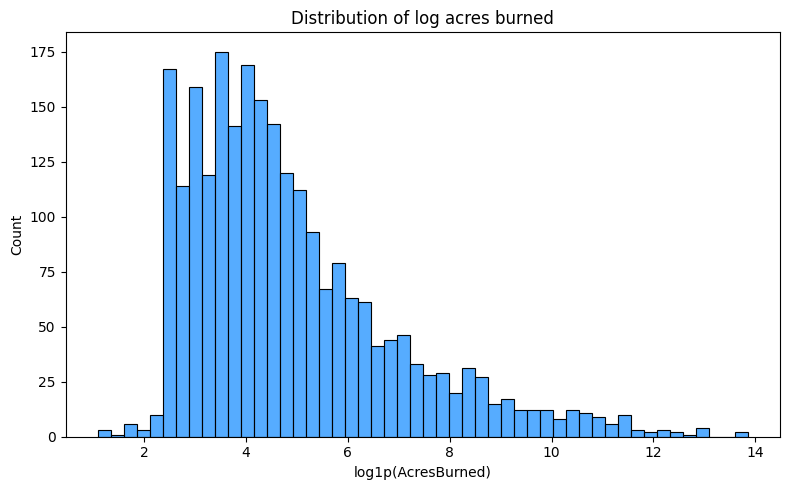

In [27]:
if "AcresBurned" in df.columns:
    acres_summary = df["AcresBurned"].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    ).to_frame().T

    display(acres_summary)
    acres_summary.to_csv(OUTPUT_DIR / "acres_burned_summary.csv", index=False)

    plt.figure(figsize=(8, 5))
    df["AcresBurned"].plot(kind="hist", bins=50)
    sns.histplot(df["AcresBurned"], 
                  bins=50, 
                  color='dodgerblue')
    plt.title("Distribution of acres burned")
    plt.xlabel("Acres burned")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    cap_95 = df["AcresBurned"].quantile(0.95)
    plt.figure(figsize=(8, 5))
    sns.histplot(df.loc[df["AcresBurned"] <= cap_95, "AcresBurned"], 
                  bins=50, 
                  color='dodgerblue')
    plt.title("Distribution of acres burned, capped at 95th percentile")
    plt.xlabel("Acres burned")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

if "log_acres" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df["log_acres"], 
                  bins=50, 
                  color='dodgerblue')
    plt.title("Distribution of log acres burned")
    plt.xlabel("log1p(AcresBurned)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


,count,mean,std,min,25%,50%,75%,max
severity_tier,,,,,,,,
Small,1311.0,38.124355,24.292440,2.0,17.00,32.0,55.00,99.5
Medium,720.0,302.723611,212.795904,100.0,139.75,215.0,406.25,993.0
Large,200.0,2266.005000,1114.702901,1000.0,1317.75,1964.5,2947.00,4929.0
Extreme,166.0,58216.133133,129542.814777,5000.0,8391.25,18524.0,48517.00,1032648.0


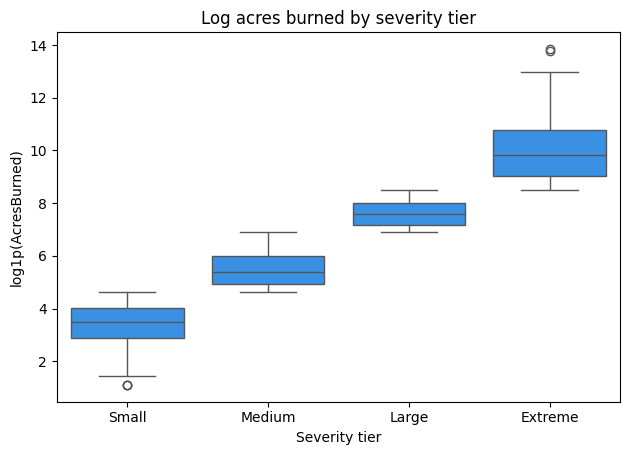

In [ ]:
if {"severity_tier", "AcresBurned"}.issubset(df.columns):
    tier_acres_summary = df.groupby("severity_tier", observed=True)["AcresBurned"].describe()
    display(tier_acres_summary)
    tier_acres_summary.to_csv(OUTPUT_DIR / "acres_by_severity_tier.csv")

    if "log_acres" in df.columns:
        ax = sns.boxplot(x="severity_tier", 
                         y="log_acres",
                         data=df, 
                         order=tier_order, 
                         color='dodgerblue')
        plt.title("Log acres burned by severity tier")
        plt.suptitle("")
        plt.xlabel("Severity tier")
        plt.ylabel("log1p(AcresBurned)")
        plt.tight_layout()
        plt.show()


## 5. Temporal and seasonal patterns

This section checks fire counts and severity composition by year and month.

This matters for modeling because the project uses a time-based split.


,count
year,
2016,149
2017,411
2018,300
2019,257
2020,241
2021,179
2022,131
2023,121
2024,608


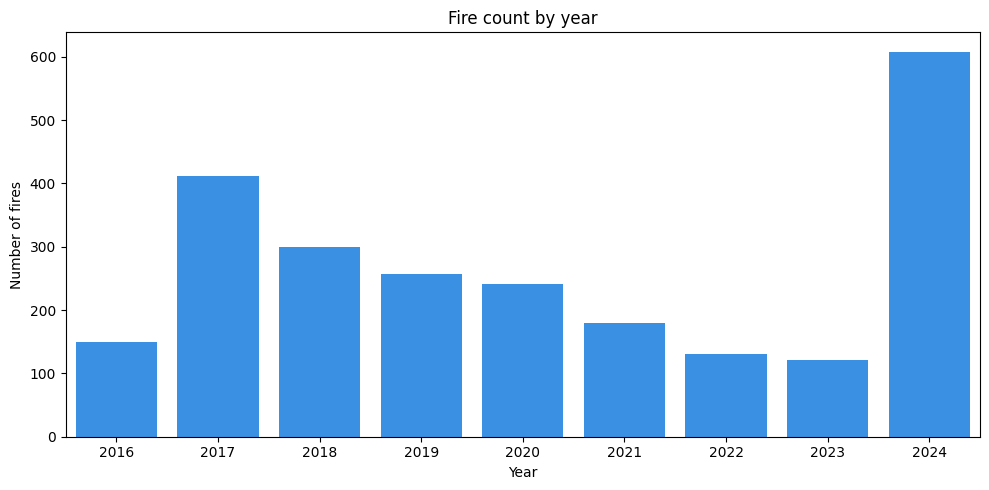

,count
month,
1,12
2,11
3,13
4,42
5,204
6,538
7,611
8,410
9,262


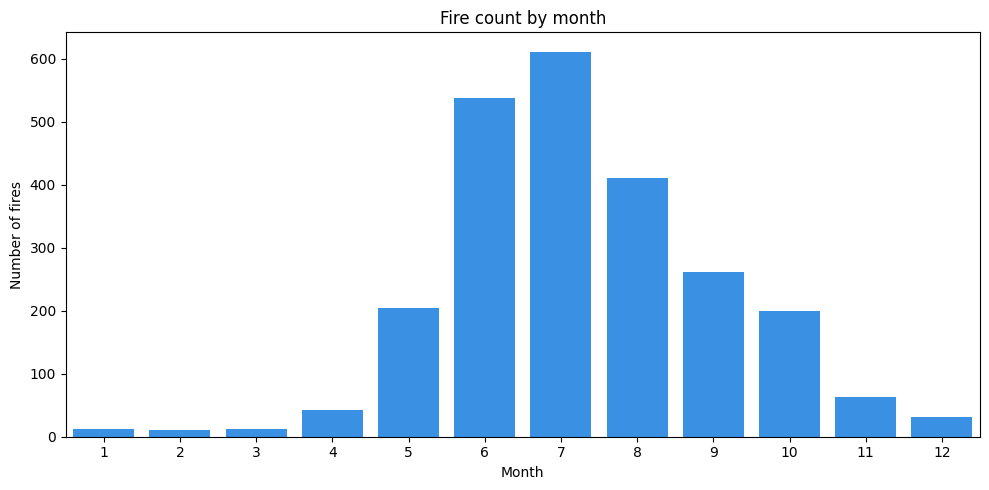

In [25]:
if "year" in df.columns:
    year_counts = df["year"].value_counts().sort_index()
    display(year_counts.to_frame("count"))
    year_counts.to_csv(OUTPUT_DIR / "fire_counts_by_year.csv")

    plt.figure(figsize=(10, 5))
    sns.barplot(x=year_counts.index, 
                y=year_counts.values, 
                color='dodgerblue')
    plt.title("Fire count by year")
    plt.xlabel("Year")
    plt.ylabel("Number of fires")
    plt.tight_layout()
    plt.show()

if "month" in df.columns:
    month_counts = df["month"].value_counts().sort_index()
    display(month_counts.to_frame("count"))
    month_counts.to_csv(OUTPUT_DIR / "fire_counts_by_month.csv")

    plt.figure(figsize=(10, 5))
    sns.barplot(x=month_counts.index, 
                y=month_counts.values, 
                color='dodgerblue')
    plt.title("Fire count by month")
    plt.xlabel("Month")
    plt.ylabel("Number of fires")
    plt.tight_layout()
    plt.show()


severity_tier,Small,Medium,Large,Extreme
year,,,,
2016,67,49,19,14
2017,220,117,38,36
2018,158,92,32,18
2019,136,86,25,10
2020,83,103,26,29
2021,86,63,13,17
2022,68,46,8,9
2023,71,32,10,8
2024,422,132,29,25


severity_tier,Small,Medium,Large,Extreme
year,,,,
2016,0.450,0.329,0.128,0.094
2017,0.535,0.285,0.092,0.088
2018,0.527,0.307,0.107,0.060
2019,0.529,0.335,0.097,0.039
2020,0.344,0.427,0.108,0.120
2021,0.480,0.352,0.073,0.095
2022,0.519,0.351,0.061,0.069
2023,0.587,0.264,0.083,0.066
2024,0.694,0.217,0.048,0.041


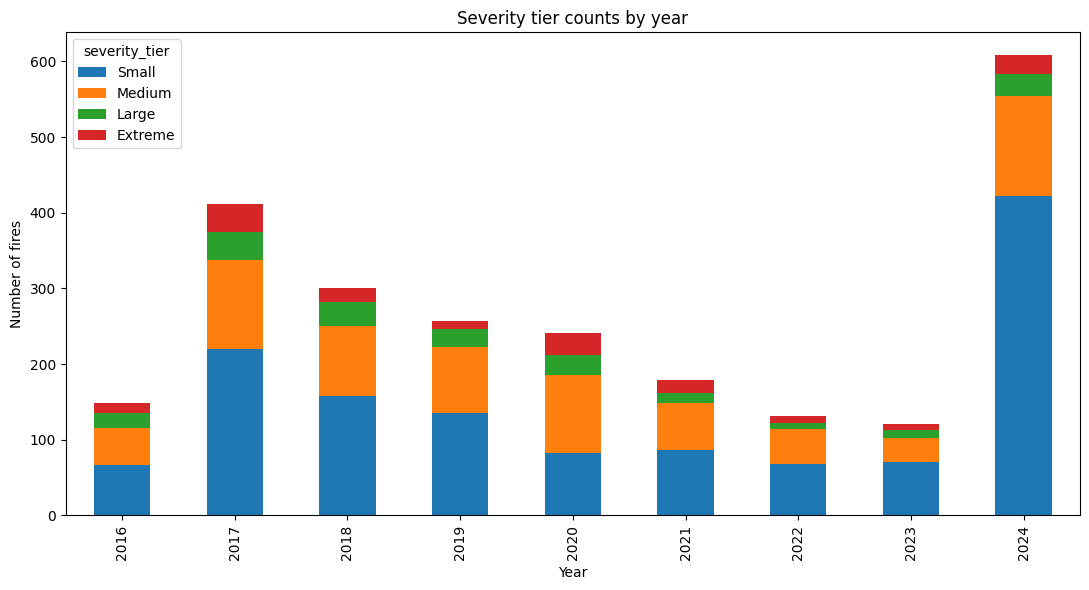

severity_tier,Small,Medium,Large,Extreme
month,,,,
1,8,4,0,0
2,5,4,2,0
3,8,5,0,0
4,25,14,3,0
5,120,65,15,4
6,299,174,47,18
7,329,192,46,44
8,209,115,39,47
9,137,71,26,28


severity_tier,Small,Medium,Large,Extreme
month,,,,
1,0.667,0.333,0.000,0.000
2,0.455,0.364,0.182,0.000
3,0.615,0.385,0.000,0.000
4,0.595,0.333,0.071,0.000
5,0.588,0.319,0.074,0.020
6,0.556,0.323,0.087,0.033
7,0.538,0.314,0.075,0.072
8,0.510,0.280,0.095,0.115
9,0.523,0.271,0.099,0.107


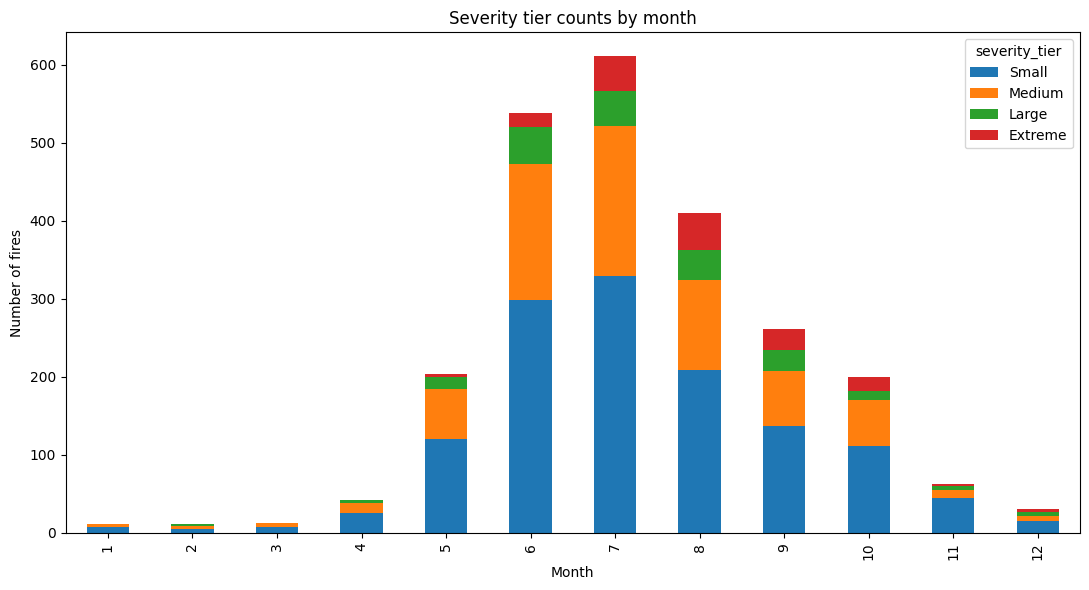

In [10]:
if {"year", "severity_tier"}.issubset(df.columns):
    yearly_tiers = pd.crosstab(df["year"], df["severity_tier"])
    yearly_tier_pct = pd.crosstab(df["year"], df["severity_tier"], normalize="index").round(3)

    display(yearly_tiers)
    display(yearly_tier_pct)

    yearly_tiers.to_csv(OUTPUT_DIR / "severity_counts_by_year.csv")
    yearly_tier_pct.to_csv(OUTPUT_DIR / "severity_percent_by_year.csv")

    yearly_tiers.plot(kind="bar", stacked=True, figsize=(11, 6))
    plt.title("Severity tier counts by year")
    plt.xlabel("Year")
    plt.ylabel("Number of fires")
    plt.tight_layout()
    plt.show()

if {"month", "severity_tier"}.issubset(df.columns):
    monthly_tiers = pd.crosstab(df["month"], df["severity_tier"])
    monthly_tier_pct = pd.crosstab(df["month"], df["severity_tier"], normalize="index").round(3)

    display(monthly_tiers)
    display(monthly_tier_pct)

    monthly_tiers.to_csv(OUTPUT_DIR / "severity_counts_by_month.csv")
    monthly_tier_pct.to_csv(OUTPUT_DIR / "severity_percent_by_month.csv")

    monthly_tiers.plot(kind="bar", stacked=True, figsize=(11, 6))
    plt.title("Severity tier counts by month")
    plt.xlabel("Month")
    plt.ylabel("Number of fires")
    plt.tight_layout()
    plt.show()


## 6. Spatial patterns

These are simple longitude/latitude scatter plots, not formal maps. They are useful for quickly checking whether large fires cluster geographically.


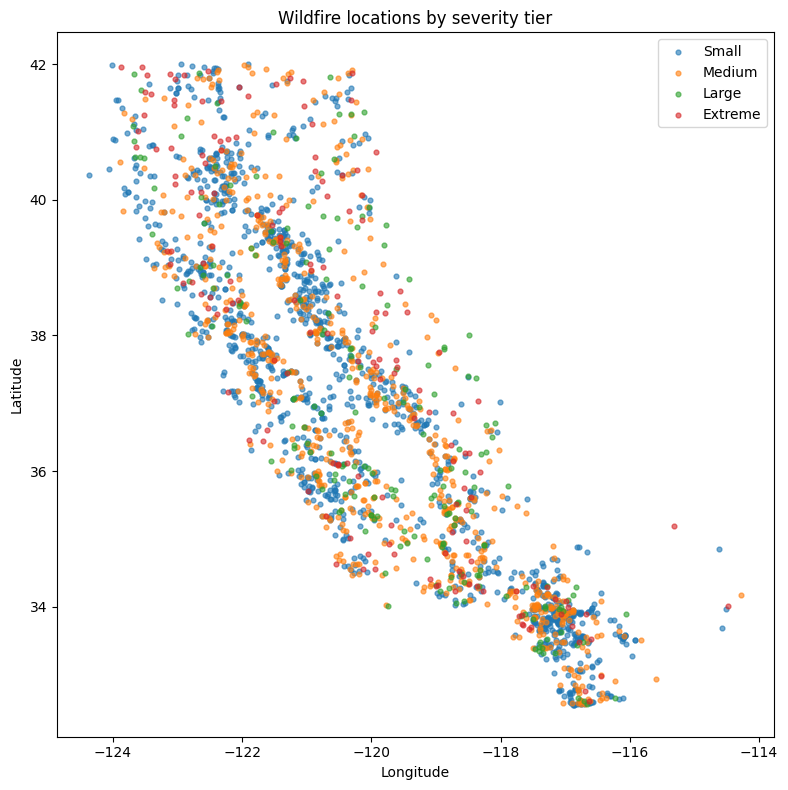

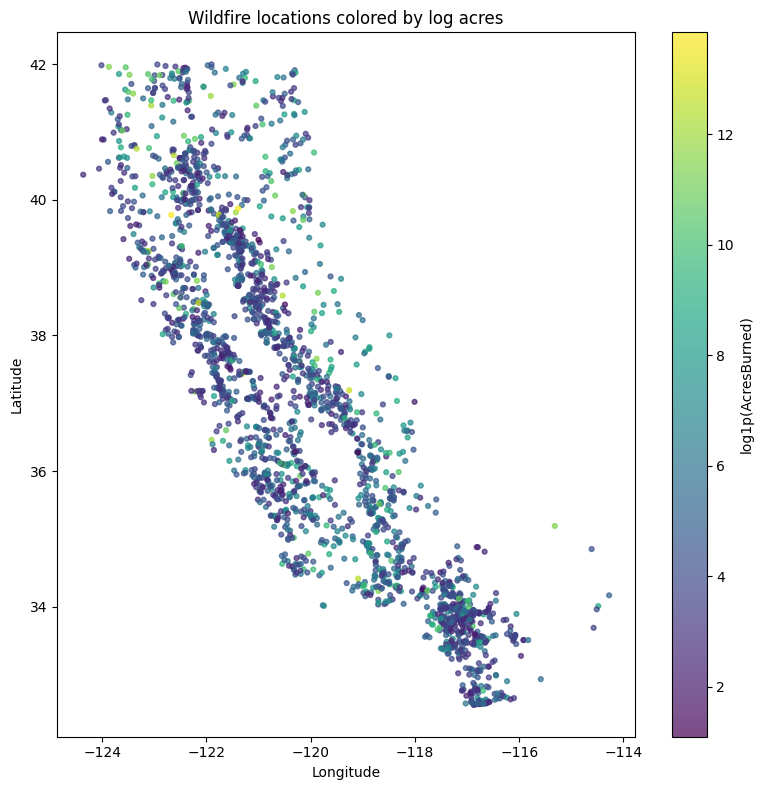

In [11]:
if {"Longitude", "Latitude", "severity_tier"}.issubset(df.columns):
    plt.figure(figsize=(8, 8))
    for tier in tier_order:
        sub = df[df["severity_tier"] == tier]
        if len(sub) == 0:
            continue
        plt.scatter(sub["Longitude"], sub["Latitude"], s=12, alpha=0.6, label=tier)

    plt.title("Wildfire locations by severity tier")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

if {"Longitude", "Latitude", "log_acres"}.issubset(df.columns):
    plt.figure(figsize=(8, 8))
    sc = plt.scatter(df["Longitude"], df["Latitude"], c=df["log_acres"], s=12, alpha=0.7)
    plt.title("Wildfire locations colored by log acres")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.colorbar(sc, label="log1p(AcresBurned)")
    plt.tight_layout()
    plt.show()


## 7. gridMET weather and fire-danger variables by severity tier

Expected directional patterns:

- Larger fires may occur under higher VPD, ERC, Burning Index, temperature, and wind.
- Larger fires may occur under lower relative humidity and lower fuel moisture.


,tmmx_F_7d_mean,tmmn_F_7d_mean,vpd_kPa_7d_mean,vs_m_s_7d_mean,rmin_pct_7d_mean,pr_mm_30d_sum,erc_7d_mean,bi_7d_mean,fm100_pct_7d_mean,fm1000_pct_30d_mean
severity_tier,,,,,,,,,,
Small,87.941,57.830,1.967,3.171,21.957,0.0,64.286,49.857,8.671,10.493
Medium,88.687,58.100,2.079,3.207,20.393,0.0,68.429,51.857,8.079,9.926
Large,86.656,56.981,2.036,3.171,18.321,0.0,71.214,53.214,7.557,9.480
Extreme,88.893,57.470,2.183,2.857,17.114,0.0,75.000,53.571,6.886,8.742


,tmmx_F_7d_mean,tmmn_F_7d_mean,vpd_kPa_7d_mean,vs_m_s_7d_mean,rmin_pct_7d_mean,pr_mm_30d_sum,erc_7d_mean,bi_7d_mean,fm100_pct_7d_mean,fm1000_pct_30d_mean
severity_tier,,,,,,,,,,
Small,86.810,57.695,2.056,3.358,23.365,6.125,64.155,50.258,9.130,10.715
Medium,87.694,58.267,2.146,3.392,21.802,4.786,67.048,52.862,8.611,10.256
Large,86.146,57.154,2.103,3.269,20.686,5.134,69.009,53.418,8.225,9.878
Extreme,87.585,58.710,2.282,3.020,18.874,2.852,73.608,53.615,7.443,8.844


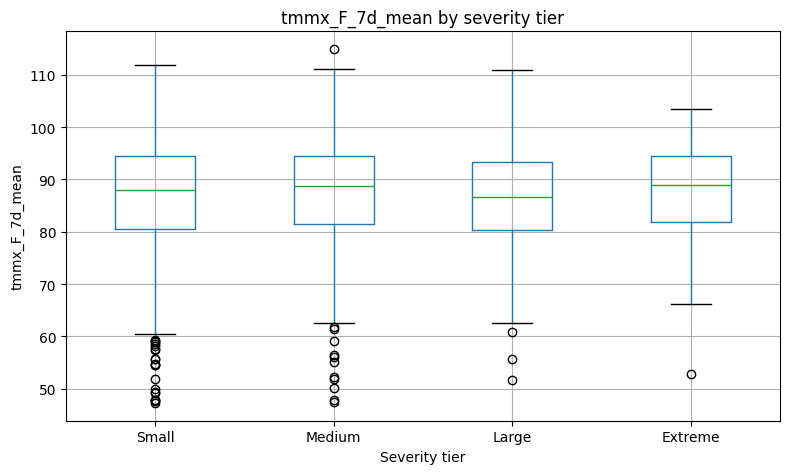

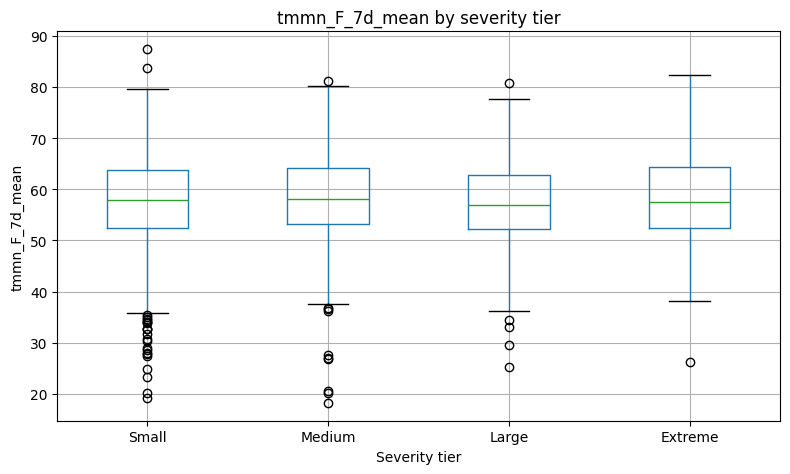

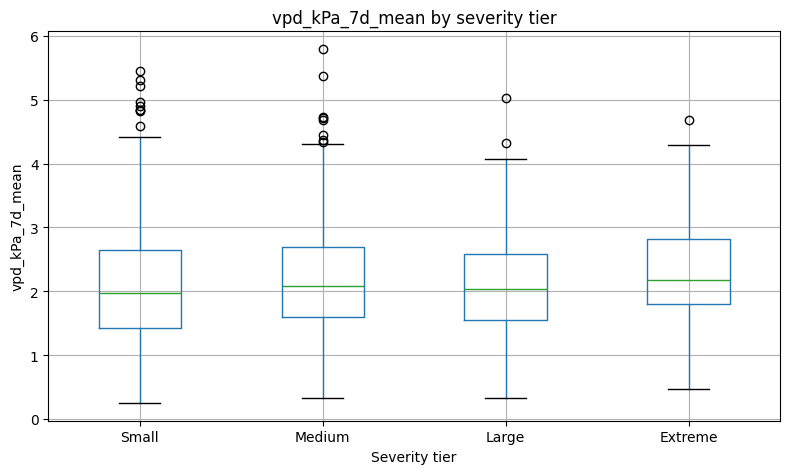

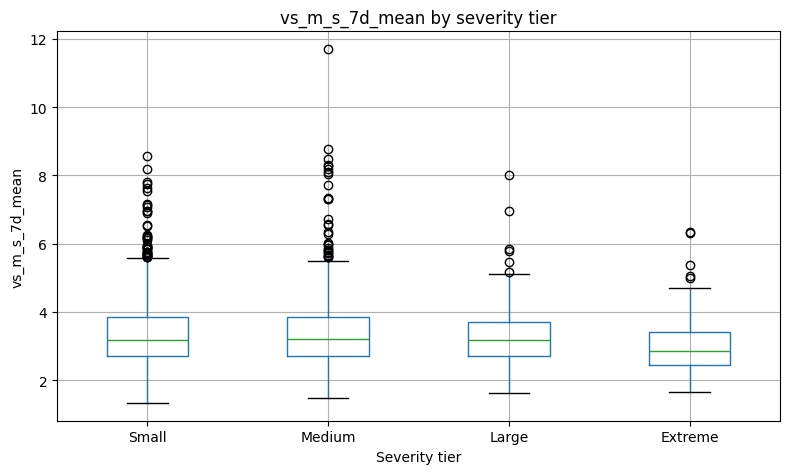

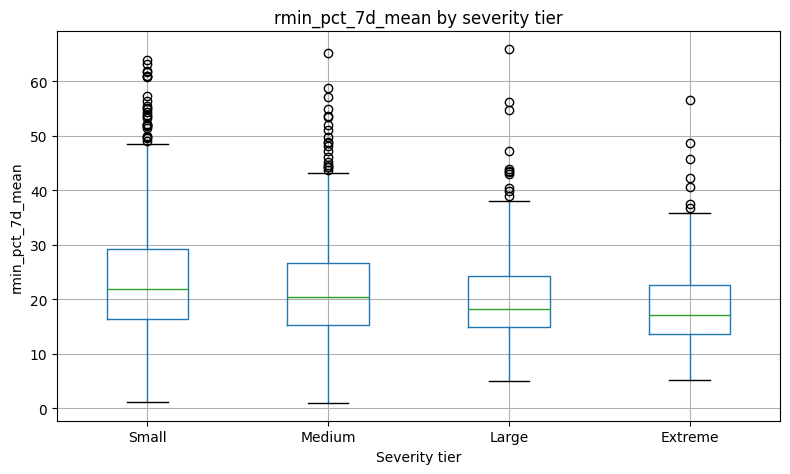

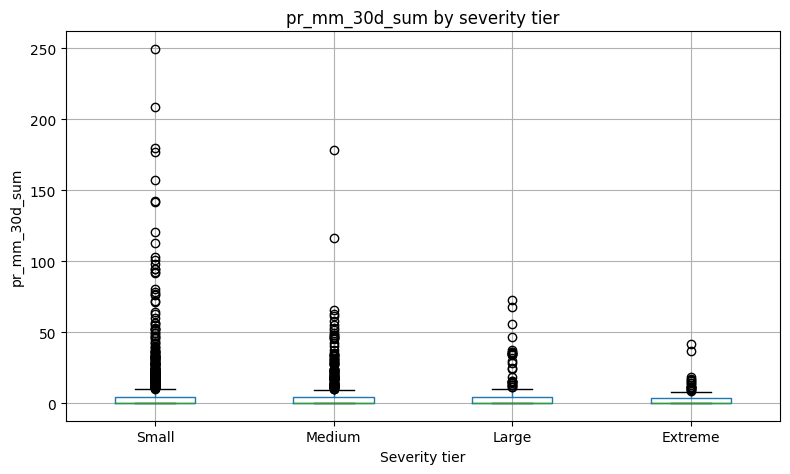

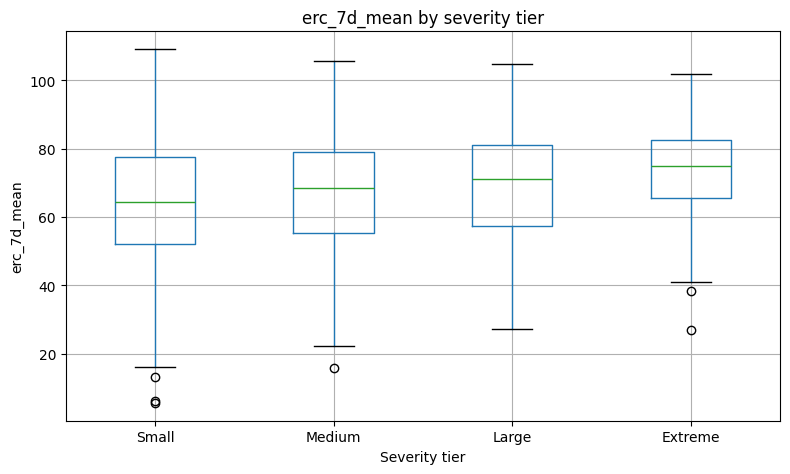

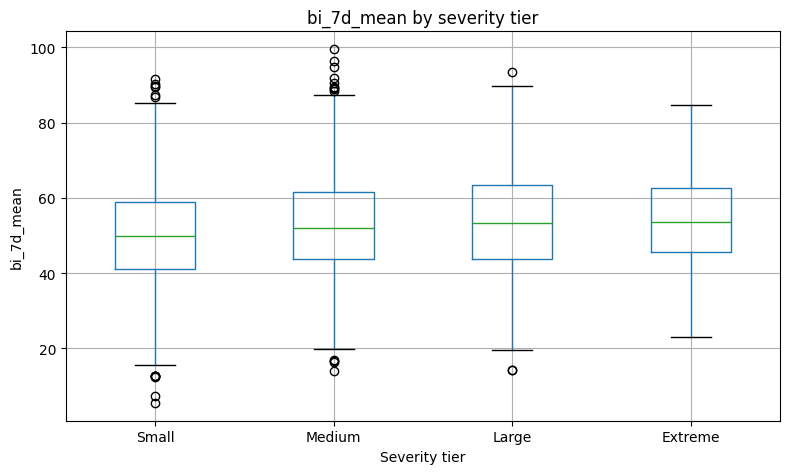

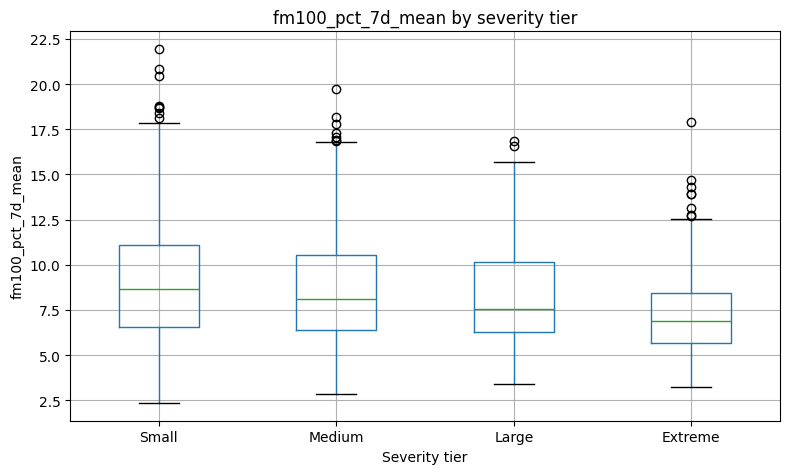

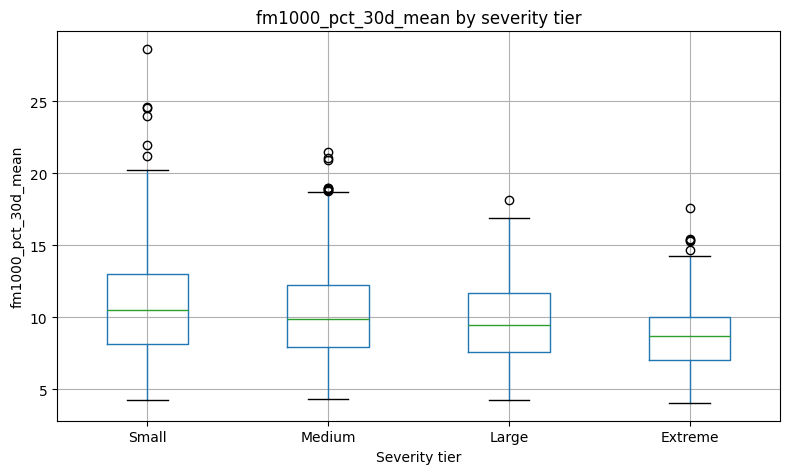

In [12]:
if "severity_tier" in df.columns and weather_cols:
    weather_median = df.groupby("severity_tier", observed=True)[weather_cols].median().round(3)
    weather_mean = df.groupby("severity_tier", observed=True)[weather_cols].mean().round(3)

    display(weather_median)
    display(weather_mean)

    weather_median.to_csv(OUTPUT_DIR / "weather_median_by_tier.csv")
    weather_mean.to_csv(OUTPUT_DIR / "weather_mean_by_tier.csv")

    for col in weather_cols:
        ax = df.boxplot(column=col, by="severity_tier", figsize=(8, 5))
        plt.title(f"{col} by severity tier")
        plt.suptitle("")
        plt.xlabel("Severity tier")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


## 8. Terrain variables by severity tier

Terrain can affect fire spread by shaping slope, elevation, and exposure.


,elevation,slope_degrees,aspect_degrees,northness,eastness
severity_tier,,,,,
Small,361.971,4.0,208.0,-0.139,-0.342
Medium,393.131,4.0,205.0,-0.070,-0.225
Large,571.132,5.0,197.0,-0.174,-0.182
Extreme,638.145,8.0,203.0,-0.216,-0.199


,elevation,slope_degrees,aspect_degrees,northness,eastness
severity_tier,,,,,
Small,465.027,5.167,190.133,-0.089,-0.154
Medium,529.927,5.647,184.371,-0.032,-0.114
Large,781.363,7.500,176.610,-0.040,-0.091
Extreme,870.885,9.331,187.500,-0.120,-0.086


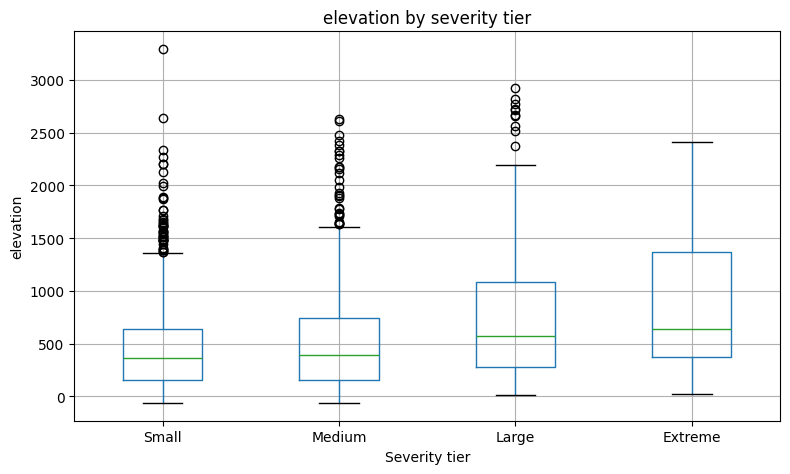

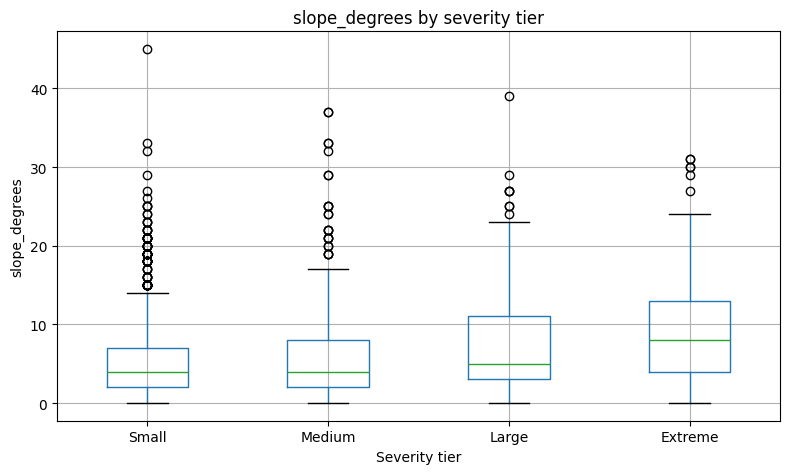

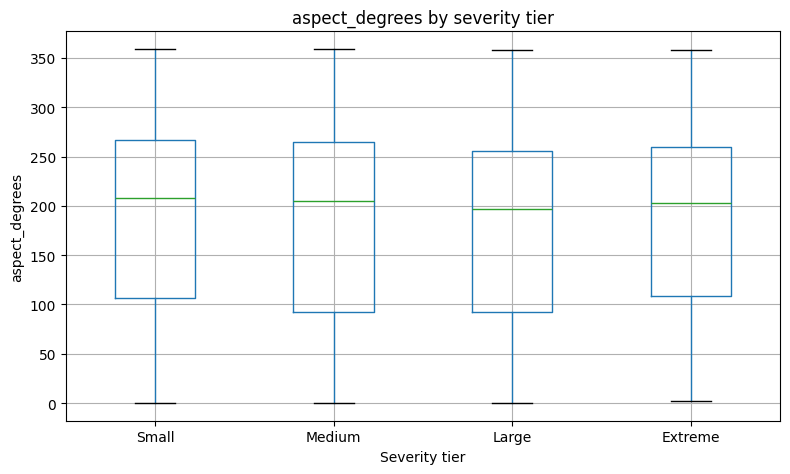

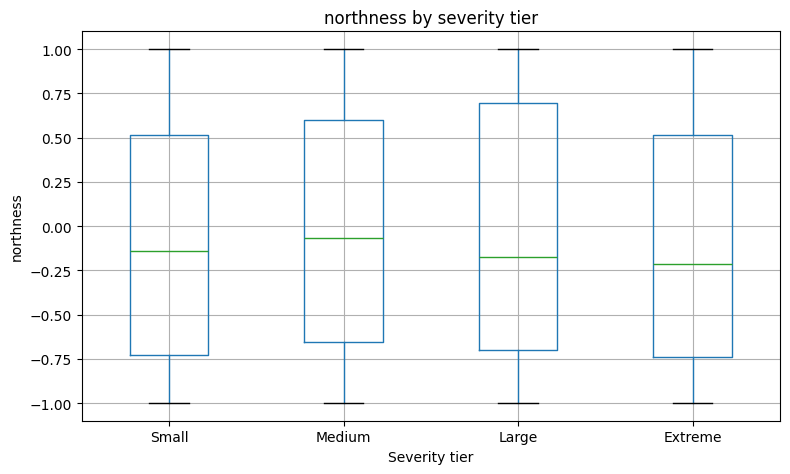

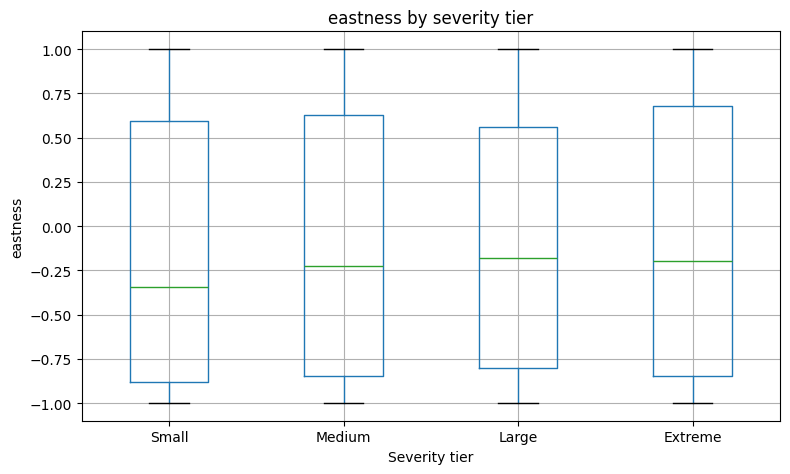

In [13]:
if "severity_tier" in df.columns and terrain_cols:
    terrain_median = df.groupby("severity_tier", observed=True)[terrain_cols].median().round(3)
    terrain_mean = df.groupby("severity_tier", observed=True)[terrain_cols].mean().round(3)

    display(terrain_median)
    display(terrain_mean)

    terrain_median.to_csv(OUTPUT_DIR / "terrain_median_by_tier.csv")
    terrain_mean.to_csv(OUTPUT_DIR / "terrain_mean_by_tier.csv")

    for col in terrain_cols:
        ax = df.boxplot(column=col, by="severity_tier", figsize=(8, 5))
        plt.title(f"{col} by severity tier")
        plt.suptitle("")
        plt.xlabel("Severity tier")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


## 9. USDM drought variables by severity tier

This section checks whether larger fires are more often associated with drought conditions.


,count,mean,median,min,max
severity_tier,,,,,
Small,1305,0.559,0.0,0.0,4.0
Medium,716,0.797,0.0,0.0,4.0
Large,200,0.755,0.0,0.0,4.0
Extreme,166,0.922,0.0,0.0,4.0


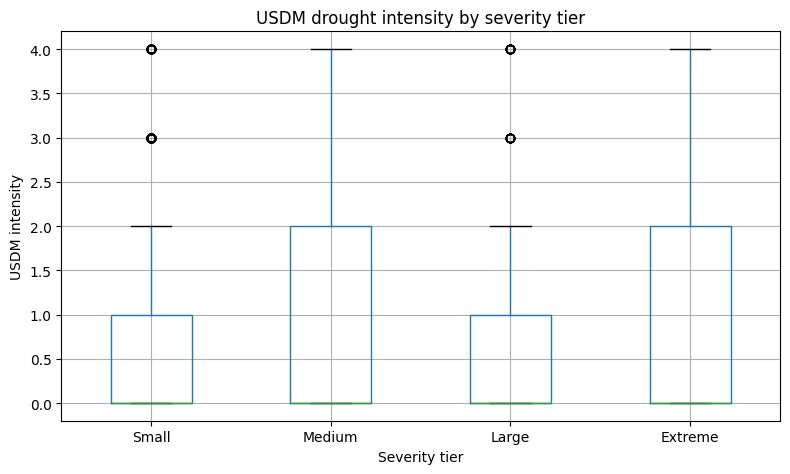

usdm_intensity,0.0,1.0,2.0,3.0,4.0
severity_tier,,,,,
Small,0.743,0.077,0.089,0.061,0.030
Medium,0.659,0.089,0.110,0.077,0.064
Large,0.685,0.100,0.070,0.065,0.080
Extreme,0.602,0.133,0.072,0.127,0.066


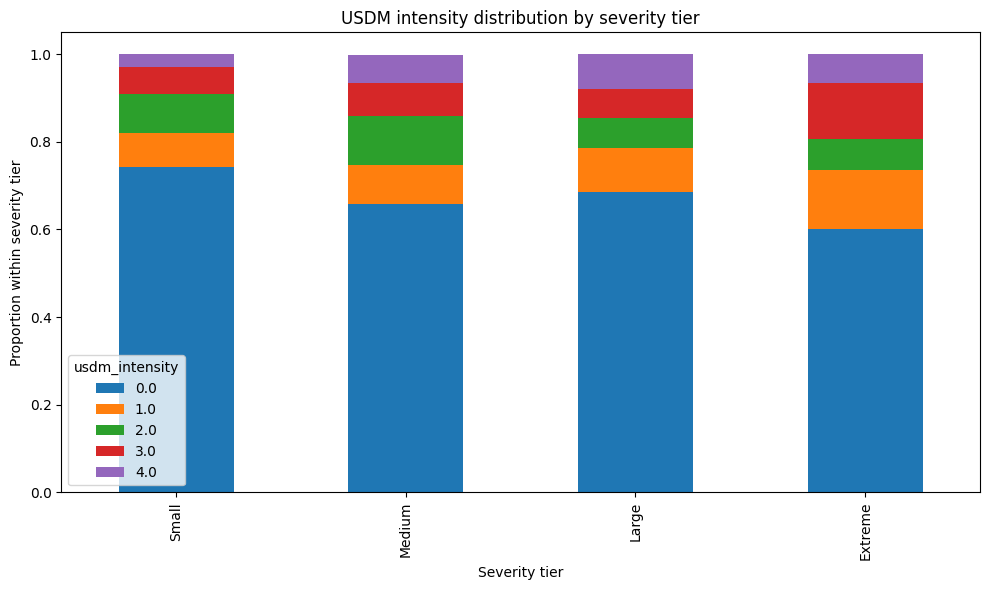

,is_abnormally_dry_D0_plus,is_drought_D1_plus,is_severe_D2_plus,is_extreme_D3_plus
severity_tier,,,,
Small,0.444,0.257,0.180,0.091
Medium,0.511,0.341,0.251,0.141
Large,0.520,0.315,0.215,0.145
Extreme,0.536,0.398,0.265,0.193


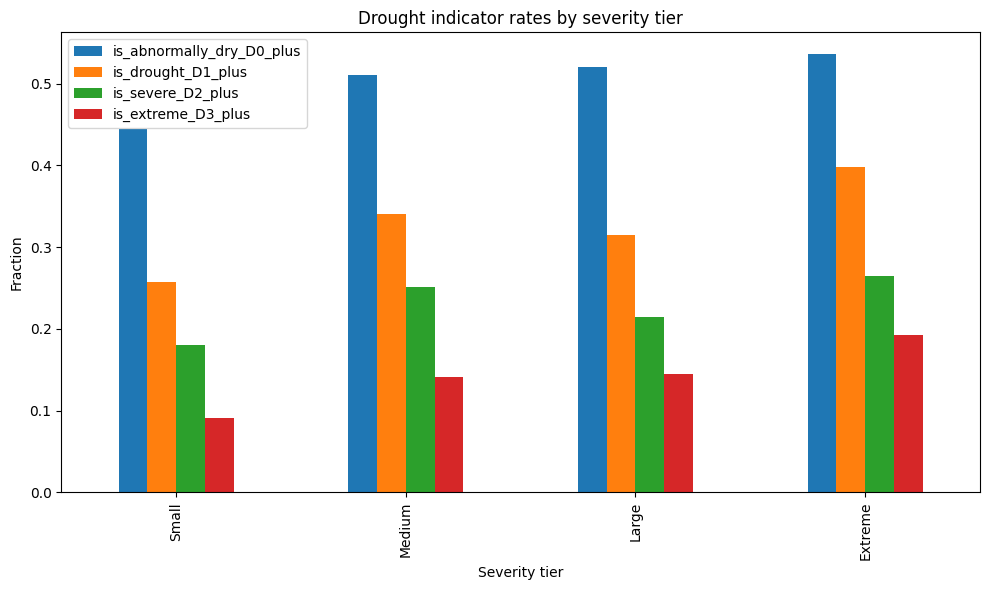

In [14]:
if "usdm_intensity" in df.columns:
    drought_summary = df.groupby("severity_tier", observed=True)["usdm_intensity"].agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
    ).round(3)

    display(drought_summary)
    drought_summary.to_csv(OUTPUT_DIR / "drought_intensity_by_tier_summary.csv")

    ax = df.boxplot(column="usdm_intensity", by="severity_tier", figsize=(8, 5))
    plt.title("USDM drought intensity by severity tier")
    plt.suptitle("")
    plt.xlabel("Severity tier")
    plt.ylabel("USDM intensity")
    plt.tight_layout()
    plt.show()

if {"usdm_intensity", "severity_tier"}.issubset(df.columns):
    drought_cross = pd.crosstab(
        df["severity_tier"],
        df["usdm_intensity"],
        normalize="index"
    ).round(3)

    display(drought_cross)
    drought_cross.to_csv(OUTPUT_DIR / "drought_intensity_by_tier_crosstab.csv")

    drought_cross.plot(kind="bar", stacked=True, figsize=(10, 6))
    plt.title("USDM intensity distribution by severity tier")
    plt.xlabel("Severity tier")
    plt.ylabel("Proportion within severity tier")
    plt.tight_layout()
    plt.show()

drought_flags = [
    c for c in [
        "is_abnormally_dry_D0_plus",
        "is_drought_D1_plus",
        "is_severe_D2_plus",
        "is_extreme_D3_plus",
    ]
    if c in df.columns
]

if drought_flags:
    drought_flag_rates = df.groupby("severity_tier", observed=True)[drought_flags].mean().round(3)
    display(drought_flag_rates)
    drought_flag_rates.to_csv(OUTPUT_DIR / "drought_flag_rates_by_tier.csv")

    drought_flag_rates.plot(kind="bar", figsize=(10, 6))
    plt.title("Drought indicator rates by severity tier")
    plt.xlabel("Severity tier")
    plt.ylabel("Fraction")
    plt.tight_layout()
    plt.show()


## 10. LANDFIRE fuel and vegetation variables by severity tier

This section focuses on broad, interpretable fuel and vegetation features.

Use caution with raw high-cardinality fields like `evt_code` and `fvt_code`.


,count
fbfm40_group,
grass,731
grass_shrub,588
nonburnable_or_other,442
shrub,333
timber_understory,164
timber_litter,139


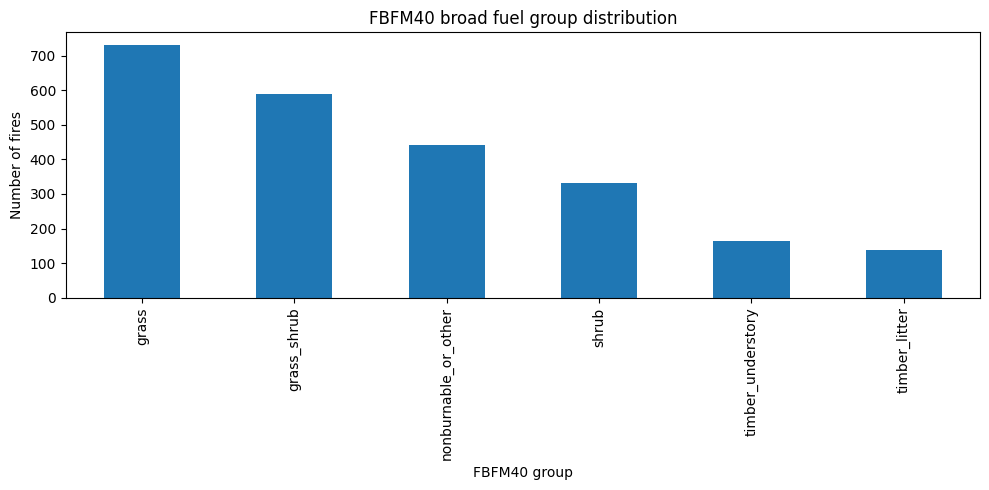

fbfm40_group,grass,grass_shrub,nonburnable_or_other,shrub,timber_litter,timber_understory
severity_tier,,,,,,
Small,0.288,0.245,0.211,0.125,0.059,0.072
Medium,0.339,0.254,0.178,0.149,0.038,0.043
Large,0.335,0.240,0.095,0.160,0.080,0.090
Extreme,0.253,0.217,0.108,0.181,0.114,0.127


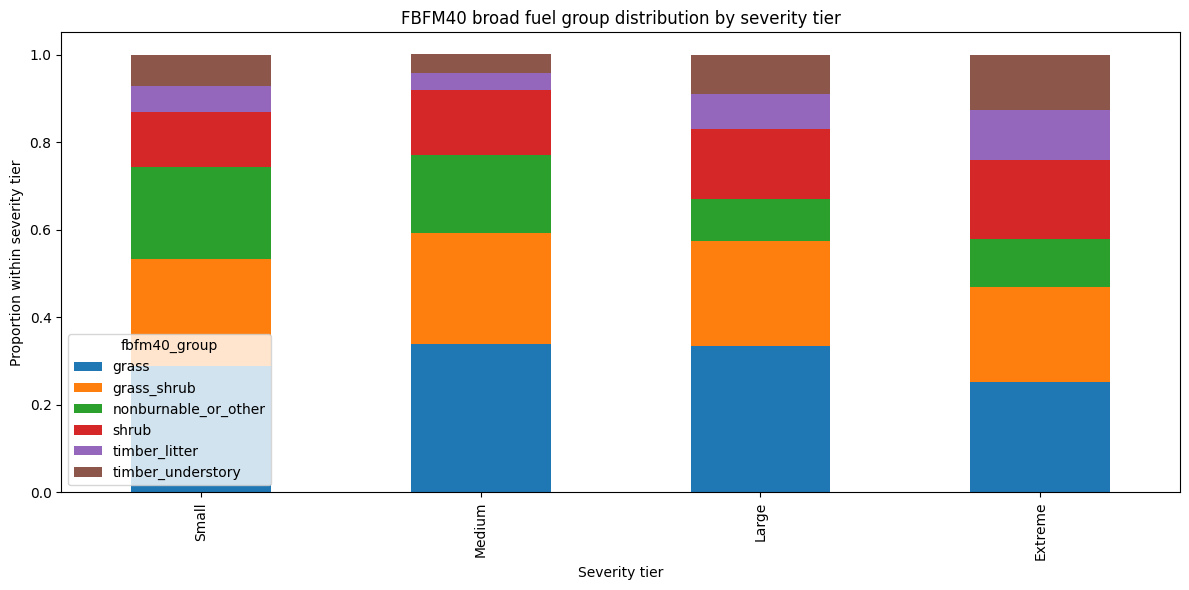

In [15]:
if "fbfm40_group" in df.columns:
    fbfm_counts = df["fbfm40_group"].value_counts(dropna=False)
    display(fbfm_counts.to_frame("count"))
    fbfm_counts.to_csv(OUTPUT_DIR / "fbfm40_group_counts.csv")

    plt.figure(figsize=(10, 5))
    fbfm_counts.plot(kind="bar")
    plt.title("FBFM40 broad fuel group distribution")
    plt.xlabel("FBFM40 group")
    plt.ylabel("Number of fires")
    plt.tight_layout()
    plt.show()

if {"fbfm40_group", "severity_tier"}.issubset(df.columns):
    fbfm_by_tier = pd.crosstab(
        df["severity_tier"],
        df["fbfm40_group"],
        normalize="index"
    ).round(3)

    display(fbfm_by_tier)
    fbfm_by_tier.to_csv(OUTPUT_DIR / "fbfm40_group_by_tier_crosstab.csv")

    fbfm_by_tier.plot(kind="bar", stacked=True, figsize=(12, 6))
    plt.title("FBFM40 broad fuel group distribution by severity tier")
    plt.xlabel("Severity tier")
    plt.ylabel("Proportion within severity tier")
    plt.tight_layout()
    plt.show()



=== evc_code ===


,count,mean,std,min,25%,50%,75%,max
evc_code,2388.0,206.466918,114.61995,11.0,131.0,225.0,332.0,384.0


,count
evc_code,
25.0,195
22.0,51
340.0,51
335.0,46
23.0,44
339.0,42
355.0,42
338.0,39
226.0,34



=== evh_code ===


,count,mean,std,min,25%,50%,75%,max
evh_code,2397.0,185.610763,102.011071,11.0,111.0,210.0,303.0,308.0


...

,count
canopy_cover,
0.0,1865
35.0,169
45.0,142
55.0,63
25.0,62
65.0,45
15.0,33
75.0,17
85.0,1



=== has_canopy_cover ===


,count,mean,std,min,25%,50%,75%,max
has_canopy_cover,2397.0,0.221944,0.41564,0.0,0.0,0.0,0.0,1.0


,count
has_canopy_cover,
0.0,1865
1.0,532


,evc_code,evh_code,fvc_code,canopy_cover,has_canopy_cover
severity_tier,,,,,
Small,222.0,208.0,111.0,0.0,0.0
Medium,228.0,214.0,112.0,0.0,0.0
Large,227.0,212.5,112.0,0.0,0.0
Extreme,229.0,212.0,111.0,0.0,0.0


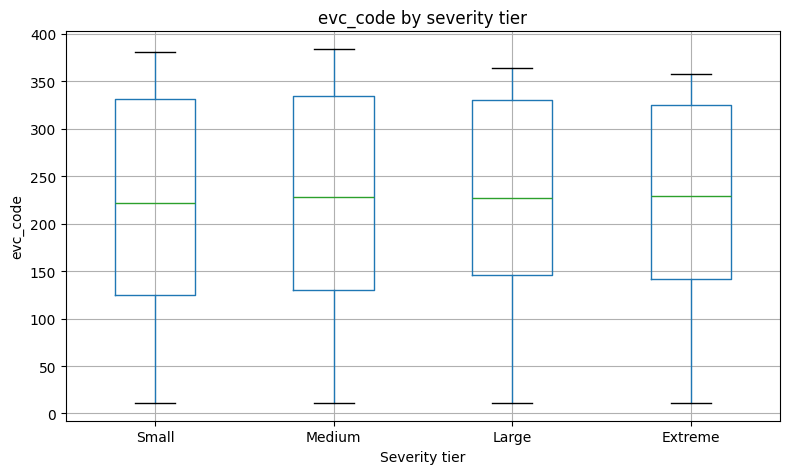

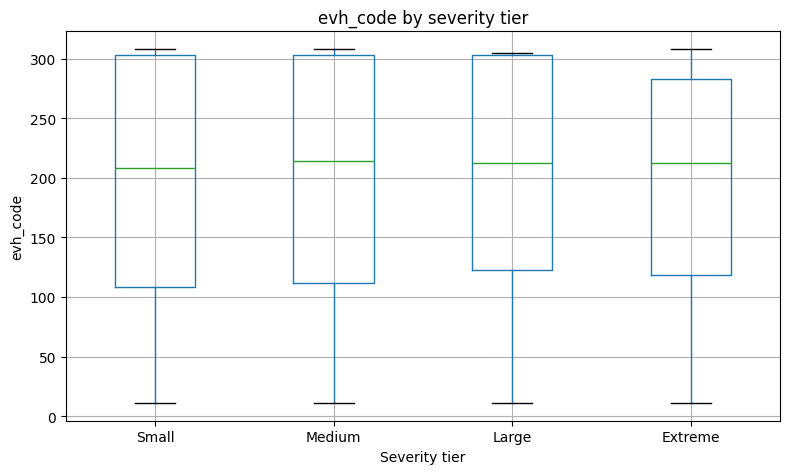

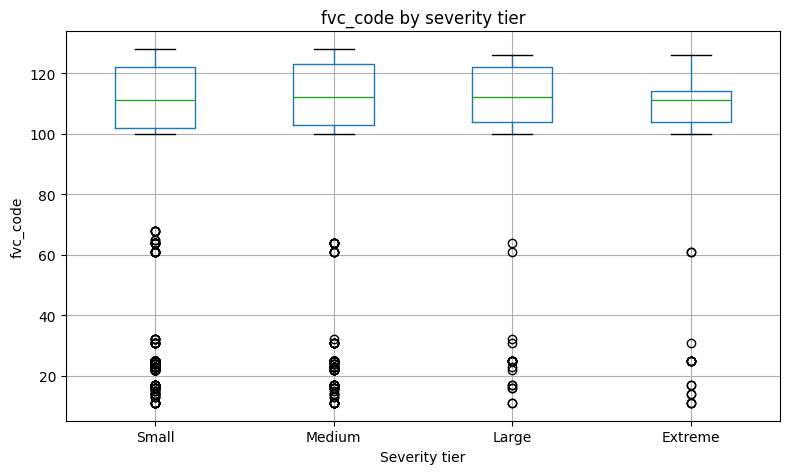

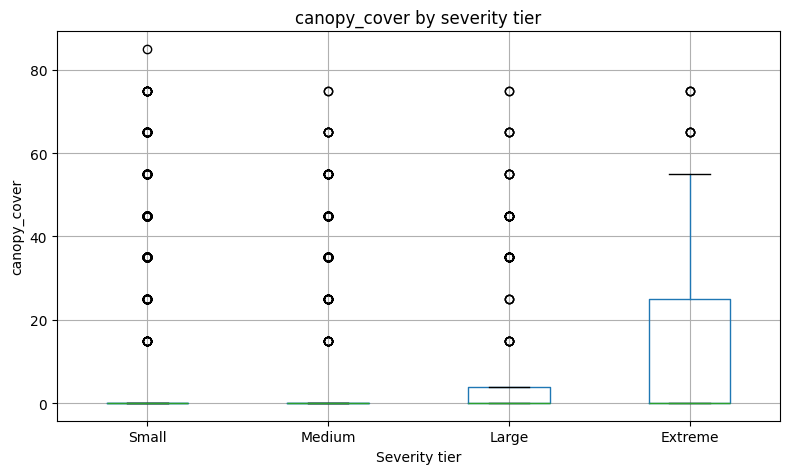

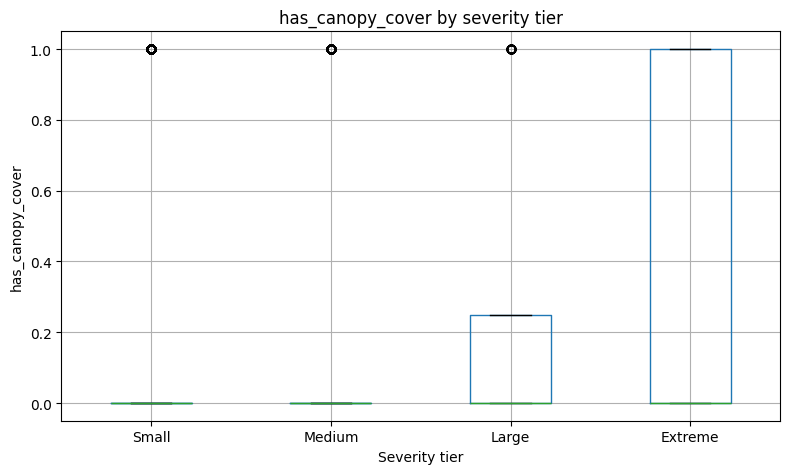


evt_code: unique values = 113


,count
evt_code,
9301.0,516
7299.0,195
7105.0,175
7092.0,139
7110.0,125
7114.0,84
9337.0,69
7980.0,60
7296.0,51



fvt_code: unique values = 91


,count
fvt_code,
2270.0,544
2905.0,195
2105.0,149
2092.0,143
2110.0,118
2114.0,98
2960.0,63
2030.0,54
2902.0,51


In [16]:
numeric_veg_cols = [
    c for c in ["evc_code", "evh_code", "fvc_code", "canopy_cover", "has_canopy_cover"]
    if c in df.columns
]

for col in numeric_veg_cols:
    print(f"\n=== {col} ===")
    display(df[col].describe().to_frame().T)
    display(df[col].value_counts(dropna=False).head(20).to_frame("count"))

if numeric_veg_cols:
    veg_medians = df.groupby("severity_tier", observed=True)[numeric_veg_cols].median().round(3)
    display(veg_medians)
    veg_medians.to_csv(OUTPUT_DIR / "vegetation_numeric_medians_by_tier.csv")

    for col in numeric_veg_cols:
        ax = df.boxplot(column=col, by="severity_tier", figsize=(8, 5))
        plt.title(f"{col} by severity tier")
        plt.suptitle("")
        plt.xlabel("Severity tier")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

for col in ["evt_code", "fvt_code"]:
    if col in df.columns:
        print(f"\n{col}: unique values = {df[col].nunique(dropna=True)}")
        display(df[col].value_counts(dropna=False).head(20).to_frame("count"))


## 11. Combined feature summary by severity tier

This table compares the most important numeric features across severity tiers.


In [17]:
important_summary_cols = [
    c for c in [
        # weather/fire-danger
        "vpd_kPa_7d_mean",
        "erc_7d_mean",
        "bi_7d_mean",
        "rmin_pct_7d_mean",
        "fm100_pct_7d_mean",
        "fm1000_pct_30d_mean",
        # terrain
        "elevation",
        "slope_degrees",
        "northness",
        "eastness",
        # drought
        "usdm_intensity",
        "is_drought_D1_plus",
        "is_severe_D2_plus",
        # vegetation/fuels
        "canopy_cover",
        "has_canopy_cover",
        "evc_code",
        "evh_code",
        "fvc_code",
    ]
    if c in df.columns
]

combined_median = df.groupby("severity_tier", observed=True)[important_summary_cols].median().round(3)
combined_mean = df.groupby("severity_tier", observed=True)[important_summary_cols].mean().round(3)

display(combined_median)
display(combined_mean)

combined_median.to_csv(OUTPUT_DIR / "combined_feature_medians_by_tier.csv")
combined_mean.to_csv(OUTPUT_DIR / "combined_feature_means_by_tier.csv")


,vpd_kPa_7d_mean,erc_7d_mean,bi_7d_mean,rmin_pct_7d_mean,fm100_pct_7d_mean,fm1000_pct_30d_mean,elevation,slope_degrees,northness,eastness,usdm_intensity,is_drought_D1_plus,is_severe_D2_plus,canopy_cover,has_canopy_cover,evc_code,evh_code,fvc_code
severity_tier,,,,,,,,,,,,,,,,,,
Small,1.967,64.286,49.857,21.957,8.671,10.493,361.971,4.0,-0.139,-0.342,0.0,0.0,0.0,0.0,0.0,222.0,208.0,111.0
Medium,2.079,68.429,51.857,20.393,8.079,9.926,393.131,4.0,-0.070,-0.225,0.0,0.0,0.0,0.0,0.0,228.0,214.0,112.0
Large,2.036,71.214,53.214,18.321,7.557,9.480,571.132,5.0,-0.174,-0.182,0.0,0.0,0.0,0.0,0.0,227.0,212.5,112.0
Extreme,2.183,75.000,53.571,17.114,6.886,8.742,638.145,8.0,-0.216,-0.199,0.0,0.0,0.0,0.0,0.0,229.0,212.0,111.0


,vpd_kPa_7d_mean,erc_7d_mean,bi_7d_mean,rmin_pct_7d_mean,fm100_pct_7d_mean,fm1000_pct_30d_mean,elevation,slope_degrees,northness,eastness,usdm_intensity,is_drought_D1_plus,is_severe_D2_plus,canopy_cover,has_canopy_cover,evc_code,evh_code,fvc_code
severity_tier,,,,,,,,,,,,,,,,,,
Small,2.056,64.155,50.258,23.365,9.130,10.715,465.027,5.167,-0.089,-0.154,0.559,0.257,0.180,9.767,0.227,198.292,177.890,94.288
Medium,2.146,67.048,52.862,21.802,8.611,10.256,529.927,5.647,-0.032,-0.114,0.797,0.341,0.251,7.250,0.186,214.167,193.326,96.940
Large,2.103,69.009,53.418,20.686,8.225,9.878,781.363,7.500,-0.040,-0.091,0.755,0.315,0.215,10.100,0.250,223.794,201.540,104.210
Extreme,2.282,73.608,53.615,18.874,7.443,8.844,870.885,9.331,-0.120,-0.086,0.922,0.398,0.265,12.380,0.307,216.861,193.928,102.886


## 12. Correlation and redundancy check

This checks redundancy among selected numeric features.

High correlations matter most for linear/logistic models. Tree models can handle redundancy better, but interpretation can still become harder.


,tmmx_F_7d_mean,tmmn_F_7d_mean,vpd_kPa_7d_mean,vs_m_s_7d_mean,rmin_pct_7d_mean,pr_mm_30d_sum,erc_7d_mean,bi_7d_mean,fm100_pct_7d_mean,fm1000_pct_30d_mean,elevation,slope_degrees,northness,eastness,usdm_intensity,canopy_cover,has_canopy_cover,evc_code,evh_code,fvc_code
tmmx_F_7d_mean,1.00,0.81,0.90,-0.17,-0.51,-0.32,0.54,0.44,-0.55,-0.42,-0.20,-0.14,0.02,0.03,0.00,-0.04,-0.02,0.04,0.05,-0.00
tmmn_F_7d_mean,0.81,1.00,0.78,-0.17,-0.27,-0.28,0.53,0.42,-0.52,-0.46,-0.16,-0.01,0.00,0.02,-0.00,-0.03,-0.02,0.01,0.02,-0.03
vpd_kPa_7d_mean,0.90,0.78,1.00,-0.17,-0.72,-0.28,0.76,0.64,-0.76,-0.61,-0.03,-0.06,0.03,0.05,0.05,0.00,0.02,0.05,0.06,0.04
vs_m_s_7d_mean,-0.17,-0.17,-0.17,1.00,0.12,0.04,-0.15,0.30,0.14,0.16,-0.14,-0.05,0.01,0.08,-0.03,-0.04,-0.06,0.00,0.00,-0.03
rmin_pct_7d_mean,-0.51,-0.27,-0.72,0.12,1.00,0.27,-0.81,-0.72,0.84,0.63,-0.23,-0.03,-0.02,-0.05,-0.06,-0.02,-0.05,-0.06,-0.06,-0.08
pr_mm_30d_sum,-0.32,-0.28,-0.28,0.04,0.27,1.00,-0.39,-0.36,0.31,0.42,0.04,0.03,-0.03,-0.01,-0.02,0.08,0.06,0.01,0.00,0.05
erc_7d_mean,0.54,0.53,0.76,-0.15,-0.81,-0.39,1.00,0.85,-0.94,-0.90,0.28,0.12,0.02,0.06,0.14,0.06,0.09,0.03,0.03,0.06
bi_7d_mean,0.44,0.42,0.64,0.30,-0.72,-0.36,0.85,1.00,-0.80,-0.71,0.17,0.04,0.02,0.08,0.08,-0.02,0.00,0.03,0.03,0.03
fm100_pct_7d_mean,-0.55,-0.52,-0.76,0.14,0.84,0.31,-0.94,-0.80,1.00,0.75,-0.28,-0.12,-0.02,-0.05,-0.12,-0.08,-0.10,-0.05,-0.04,-0.08
fm1000_pct_30d_mean,-0.42,-0.46,-0.61,0.16,0.63,0.42,-0.90,-0.71,0.75,1.00,-0.26,-0.13,-0.02,-0.08,-0.16,-0.06,-0.09,-0.02,-0.02,-0.05


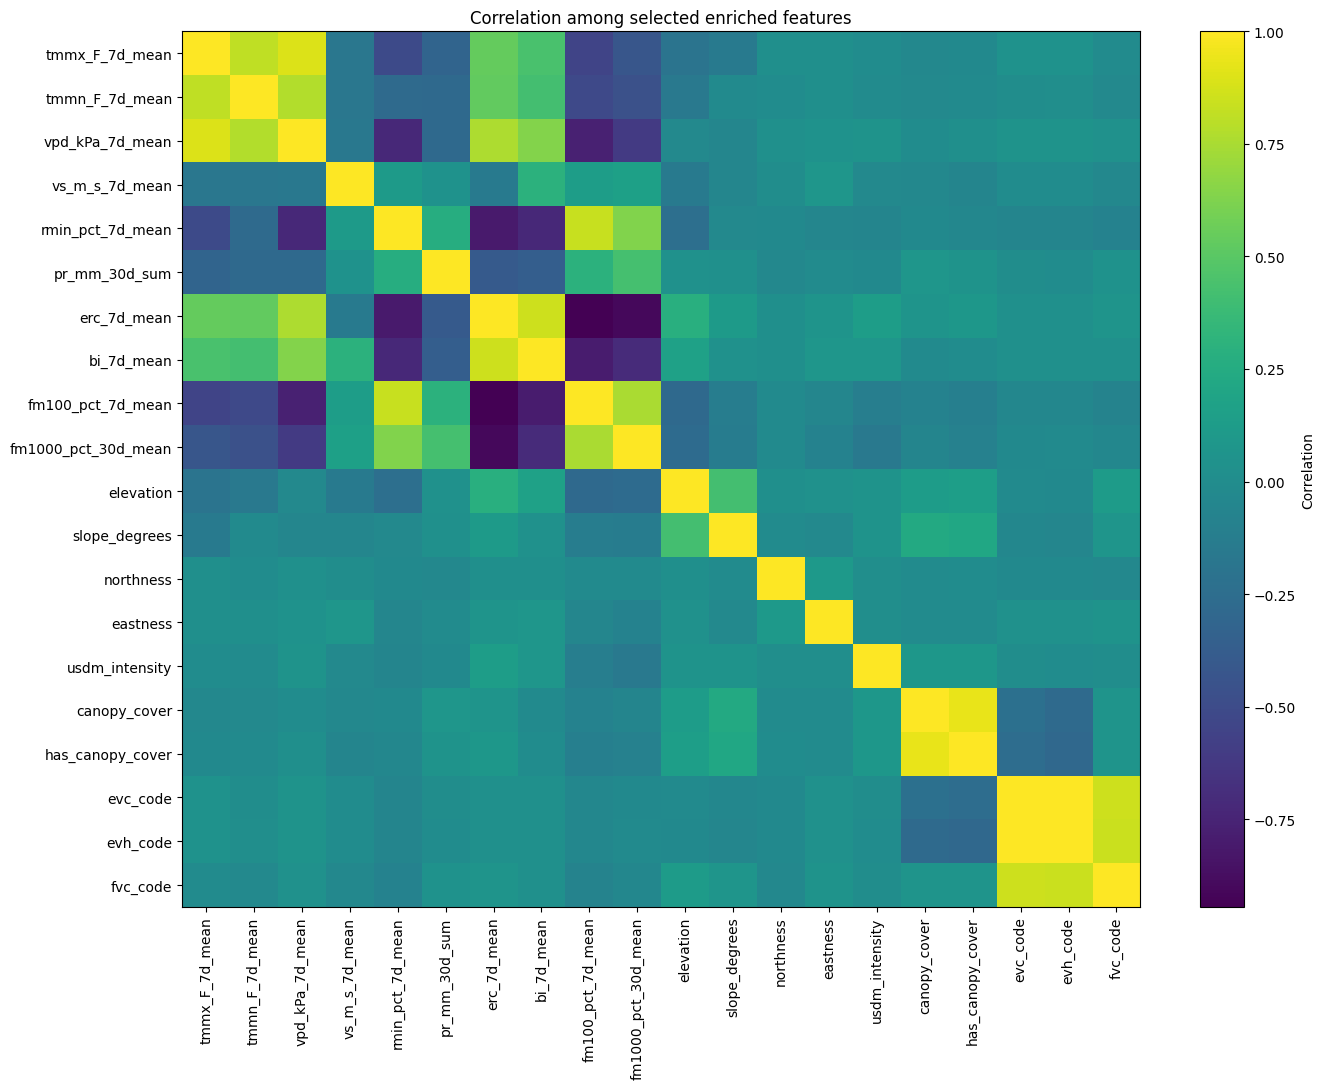

In [18]:
corr_cols = [
    c for c in [
        # weather/fire danger
        "tmmx_F_7d_mean",
        "tmmn_F_7d_mean",
        "vpd_kPa_7d_mean",
        "vs_m_s_7d_mean",
        "rmin_pct_7d_mean",
        "pr_mm_30d_sum",
        "erc_7d_mean",
        "bi_7d_mean",
        "fm100_pct_7d_mean",
        "fm1000_pct_30d_mean",
        # terrain
        "elevation",
        "slope_degrees",
        "northness",
        "eastness",
        # drought
        "usdm_intensity",
        # vegetation
        "canopy_cover",
        "has_canopy_cover",
        "evc_code",
        "evh_code",
        "fvc_code",
    ]
    if c in df.columns
]

corr = df[corr_cols].corr()
display(corr.round(2))

plt.figure(figsize=(14, 11))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation among selected enriched features")
plt.tight_layout()
plt.show()

corr.to_csv(OUTPUT_DIR / "selected_feature_correlation.csv")


In [19]:
threshold = 0.85
pairs = []

for i, col1 in enumerate(corr.columns):
    for j, col2 in enumerate(corr.columns):
        if j <= i:
            continue
        value = corr.loc[col1, col2]
        if pd.notna(value) and abs(value) >= threshold:
            pairs.append((col1, col2, value))

high_corr = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "correlation"]).sort_values(
    "correlation",
    key=lambda s: s.abs(),
    ascending=False,
)

display(high_corr)
high_corr.to_csv(OUTPUT_DIR / "high_correlation_pairs.csv", index=False)


,feature_1,feature_2,correlation
5,evc_code,evh_code,0.995722
2,erc_7d_mean,fm100_pct_7d_mean,-0.944805
4,canopy_cover,has_canopy_cover,0.933022
3,erc_7d_mean,fm1000_pct_30d_mean,-0.899851
0,tmmx_F_7d_mean,vpd_kPa_7d_mean,0.895165
6,evc_code,fvc_code,0.850536
1,erc_7d_mean,bi_7d_mean,0.850263


## 13. Time-based train/test shift check

The proposed modeling split is:

```text
Train: 2016–2021
Test: 2022–2024
```

This section checks whether the test period differs from the training period.


,count
split_candidate,
train_2016_2021,1537
test_2022_2024,860


severity_tier,Small,Medium,Large,Extreme
split_candidate,,,,
test_2022_2024,561,210,47,42
train_2016_2021,750,510,153,124


severity_tier,Small,Medium,Large,Extreme
split_candidate,,,,
test_2022_2024,0.652,0.244,0.055,0.049
train_2016_2021,0.488,0.332,0.100,0.081


,vpd_kPa_7d_mean,erc_7d_mean,bi_7d_mean,fm100_pct_7d_mean,elevation,slope_degrees,usdm_intensity,canopy_cover,has_canopy_cover
split_candidate,,,,,,,,,
test_2022_2024,2.204,70.000,53.286,7.707,405.169,4.0,0.0,0.0,0.0
train_2016_2021,1.977,65.714,50.143,8.386,402.282,4.0,0.0,0.0,0.0


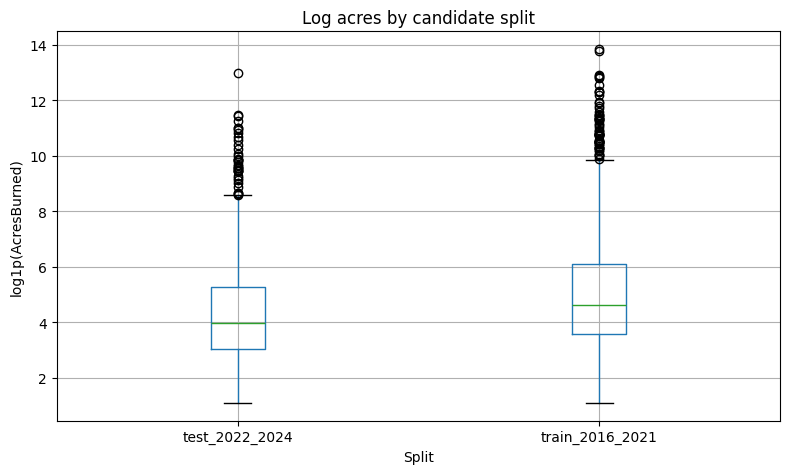

In [20]:
if "year" in df.columns:
    df["split_candidate"] = np.where(df["year"] <= 2021, "train_2016_2021", "test_2022_2024")

    split_counts = df["split_candidate"].value_counts()
    display(split_counts.to_frame("count"))

    if "severity_tier" in df.columns:
        split_tier_counts = pd.crosstab(df["split_candidate"], df["severity_tier"])
        split_tier_pct = pd.crosstab(df["split_candidate"], df["severity_tier"], normalize="index").round(3)

        display(split_tier_counts)
        display(split_tier_pct)

        split_tier_counts.to_csv(OUTPUT_DIR / "split_severity_counts.csv")
        split_tier_pct.to_csv(OUTPUT_DIR / "split_severity_percent.csv")

    split_feature_cols = [
        c for c in [
            "vpd_kPa_7d_mean",
            "erc_7d_mean",
            "bi_7d_mean",
            "fm100_pct_7d_mean",
            "elevation",
            "slope_degrees",
            "usdm_intensity",
            "canopy_cover",
            "has_canopy_cover",
        ]
        if c in df.columns
    ]

    if split_feature_cols:
        split_feature_medians = df.groupby("split_candidate")[split_feature_cols].median().round(3)
        display(split_feature_medians)
        split_feature_medians.to_csv(OUTPUT_DIR / "split_feature_medians.csv")

    if "log_acres" in df.columns:
        ax = df.boxplot(column="log_acres", by="split_candidate", figsize=(8, 5))
        plt.title("Log acres by candidate split")
        plt.suptitle("")
        plt.xlabel("Split")
        plt.ylabel("log1p(AcresBurned)")
        plt.tight_layout()
        plt.show()


## 14. Final EDA notes

Fill this section in after reviewing the outputs. These notes can be copied into the README or final report.


In [21]:
eda_notes = {
    "data_quality": "",
    "target_distribution": "",
    "acres_skew": "",
    "temporal_patterns": "",
    "spatial_patterns": "",
    "weather_fire_danger_signal": "",
    "terrain_signal": "",
    "drought_signal": "",
    "vegetation_fuel_signal": "",
    "feature_redundancy": "",
    "train_test_shift": "",
    "modeling_implications": "",
}

for key, value in eda_notes.items():
    print(f"{key}: {value}")


data_quality: 
target_distribution: 
acres_skew: 
temporal_patterns: 
spatial_patterns: 
weather_fire_danger_signal: 
terrain_signal: 
drought_signal: 
vegetation_fuel_signal: 
feature_redundancy: 
train_test_shift: 
modeling_implications: 


The final enriched dataset contains 2,397 CAL FIRE wildfire incidents joined with point-based environmental features sampled at each fire’s ignition coordinates. The final modeling table combines gridMET weather and fire-danger variables, USGS 3DEP terrain features, weekly U.S. Drought Monitor drought intensity, and LANDFIRE vegetation/fuel variables. The dataset contains no duplicate fire IDs and has low missingness across the main modeling features.

Final acres burned is highly right-skewed. Most fires in the dataset burned relatively small areas, while a small number of very large fires pulled the mean far above the median. Because of this skew, raw acreage is not ideal as the primary prediction target. The project therefore uses log-transformed acres for exploratory analysis and NWCG-derived severity tiers for classification.

The severity target is imbalanced, with Small fires forming the largest class and Large/Extreme fires being much less common. This means model evaluation should prioritize balanced accuracy, macro F1, per-class recall, and Large/Extreme recall rather than raw accuracy alone.

Weather and fire-danger features show meaningful directional patterns across severity tiers. Larger fires generally occur under drier and more fire-dangerous conditions, including higher vapor pressure deficit, higher Energy Release Component, higher Burning Index, lower relative humidity, and lower fuel moisture.

Terrain, drought, and vegetation/fuel features provide additional environmental context. Larger fires tend to occur at somewhat higher elevations and steeper slopes. Extreme fires also show higher average USDM drought intensity than Small fires, suggesting that drought adds broader moisture-context signal. LANDFIRE fuel groups differ across severity tiers, with larger fires showing greater representation in shrub and timber-related fuel groups.

Correlation analysis shows that several fire-danger features are highly redundant, especially ERC, Burning Index, fuel moisture, temperature, and VPD. This suggests that simpler linear models should use a curated feature set, while tree-based models can use a broader feature set with careful interpretation.

The proposed 2016–2021 train and 2022–2024 test split shows distribution shift, especially in severity-tier proportions. The test period contains a higher share of Small fires and fewer Large/Extreme fires than the training period. This makes the validation setup more realistic, but model performance should be interpreted carefully.

Overall, the EDA supports the project’s final modeling direction: wildfire severity is better framed as an imbalanced classification and high-severity triage problem than as exact acreage prediction. The feature patterns suggest that point-based weather, terrain, drought, and fuel data contain useful severity signal, but final fire size remains difficult to predict from environmental variables alone.

## 16. Save compact final EDA/modeling table

This optional compact file keeps the target, metadata, and selected feature groups for quick modeling experiments.


In [22]:
metadata_cols = [
    c for c in [
        "gridmet_id",
        "Name",
        "fire_start_date",
        "year",
        "month",
        "Latitude",
        "Longitude",
        "AcresBurned",
        "log_acres",
        "nwcg_size_class",
        "severity_tier",
    ]
    if c in df.columns
]

selected_weather_cols = weather_cols
selected_terrain_cols = [c for c in ["elevation", "slope_degrees", "northness", "eastness"] if c in df.columns]
selected_drought_cols = [c for c in drought_cols if c != "usdm_category_display"]
selected_veg_cols = [c for c in veg_cols if c != "has_canopy_cover"]
if "has_canopy_cover" in df.columns:
    selected_veg_cols.append("has_canopy_cover")

compact_cols = metadata_cols + selected_weather_cols + selected_terrain_cols + selected_drought_cols + selected_veg_cols
compact_cols = list(dict.fromkeys(compact_cols))

compact = df[compact_cols].copy()

COMPACT_PATH = PROCESSED_DIR / "final_eda_model_base.csv"
compact.to_csv(COMPACT_PATH, index=False)

print("Saved:", COMPACT_PATH)
print("Shape:", compact.shape)
display(compact.head())


Saved: c:\Users\chaud\Desktop\repositories\wildfire-severity-v2\data\processed\final_eda_model_base.csv
Shape: (2397, 41)


,gridmet_id,Name,fire_start_date,year,month,Latitude,Longitude,AcresBurned,log_acres,nwcg_size_class,severity_tier,tmmx_F_7d_mean,tmmn_F_7d_mean,vpd_kPa_7d_mean,vs_m_s_7d_mean,rmin_pct_7d_mean,pr_mm_30d_sum,erc_7d_mean,bi_7d_mean,fm100_pct_7d_mean,fm1000_pct_30d_mean,elevation,slope_degrees,northness,eastness,usdm_raw,usdm_category,usdm_intensity,is_abnormally_dry_D0_plus,is_drought_D1_plus,is_severe_D2_plus,is_extreme_D3_plus,fbfm40_code,fbfm40_group,evt_code,evc_code,evh_code,canopy_cover,fvt_code,fvc_code,has_canopy_cover
0,fire_00000,Creek Fire,2016-10-10,2016,10,38.409580,-122.431720,65.0,4.189655,C,Small,76.987143,50.732857,1.351429,3.071429,26.585714,2.3,51.857143,39.000000,12.814286,10.673333,223.804140,2.0,-0.406737,-0.913545,0,D0,0.0,1.0,0.0,0.0,0.0,183.0,timber_litter,7901.0,14.0,14.0,45.0,2914.0,14.0,1.0
1,fire_00001,Taglio Fire,2016-04-24,2016,4,37.217100,-121.080360,30.0,3.433987,C,Small,84.110000,52.558571,1.652857,2.928571,25.842857,40.2,36.142857,25.000000,11.400000,18.823333,62.611248,1.0,0.173648,0.984808,3,D3,3.0,1.0,1.0,1.0,1.0,93.0,nonburnable_or_other,7984.0,64.0,64.0,0.0,2964.0,64.0,0.0
2,fire_00002,Tulloch Fire,2016-05-30,2016,5,37.927613,-120.528836,85.0,4.454347,C,Small,81.332857,54.152857,1.415714,3.242857,30.228571,2.2,50.000000,40.857143,11.014286,14.010000,254.468410,5.0,-0.406737,-0.913545,3,D3,3.0,1.0,1.0,1.0,1.0,102.0,grass,9301.0,351.0,304.0,0.0,2270.0,125.0,0.0
3,fire_00003,Metz Fire,2016-05-22,2016,5,36.381230,-121.200590,3876.0,8.262817,F,Large,77.578571,47.415714,1.264286,5.057143,29.400000,9.2,42.428571,44.000000,12.800000,15.173333,257.852000,11.0,-0.694658,0.719340,4,D4,4.0,1.0,1.0,1.0,1.0,102.0,grass,9301.0,342.0,303.0,0.0,2184.0,123.0,0.0
4,fire_00004,Wheatland Fire,2016-05-23,2016,5,34.276000,-118.354000,156.0,5.056246,D,Medium,73.104286,51.221429,0.955714,3.071429,36.528571,9.1,49.714286,39.714286,11.928571,11.576667,395.886870,10.0,-0.798636,-0.601815,4,D4,4.0,1.0,1.0,1.0,1.0,122.0,grass_shrub,7092.0,224.0,215.0,0.0,2092.0,112.0,0.0
